<a href="https://colab.research.google.com/github/angeruzzi/home-credit-default-risk/blob/main/notebooks/05_traditional_credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Traditional Credit Scoring

## Introdução

### 1. Contexto

Este notebook desenvolve o modelo tradicional de **Application Score** utilizando a base analítica consolidada nos notebooks anteriores.

A abordagem seguirá práticas tradicionais de modelagem de risco de crédito:

$$
\text{Binning}
\rightarrow
\text{Weight of Evidence}
\rightarrow
\text{Information Value}
\rightarrow
\text{Seleção de features}
\rightarrow
\text{Logistic Regression}
\rightarrow
\text{Probability of Default}
$$

O modelo terá como objetivo estimar a probabilidade de ocorrência do evento representado por `TARGET = 1`, correspondente à dificuldade de pagamento definida na base Home Credit.

Como discutido anteriormente, esse evento será tratado neste projeto como uma aproximação de **default**, respeitando as limitações da definição disponibilizada pela competição. Portanto, a probabilidade produzida pelo modelo deve ser interpretada como:

$$
PD_i = P(TARGET_i = 1 \mid X_i)
$$

em que:

- $PD_i$ representa a probabilidade estimada de dificuldade de pagamento do cliente $i$;
- $TARGET_i = 1$ representa a ocorrência do evento de interesse;
- $X_i$ representa o conjunto de características conhecidas no momento da solicitação e o histórico disponível do cliente.

A escolha da **Logistic Regression** como primeiro modelo não se limita à construção de um baseline. Essa abordagem possui ampla aplicação em credit scoring devido à sua interpretabilidade, estabilidade e facilidade de transformação da probabilidade estimada em um score de crédito.

As transformações por **Binning** e **Weight of Evidence — WoE** também permitem:

- tratar relações não lineares entre as features e o target;
- representar missing values de forma explícita;
- reduzir a sensibilidade a outliers;
- avaliar a capacidade preditiva individual por meio do **Information Value — IV**;
- produzir coeficientes cuja direção possa ser interpretada em termos de risco;
- facilitar a construção de um scorecard.

O modelo desenvolvido neste notebook será posteriormente comparado ao modelo **challenger** baseado em LightGBM.

### 2. Objetivos

Os principais objetivos deste notebook são:

1. carregar as amostras de train, validation e holdout test produzidas anteriormente;
2. definir as features elegíveis para o modelo tradicional;
3. realizar o binning das variáveis numéricas e categóricas;
4. calcular o Weight of Evidence — WoE e o Information Value — IV;
5. selecionar features com base em critérios estatísticos, preditivos e de negócio;
6. transformar as amostras utilizando os bins definidos exclusivamente no train;
7. estimar uma Logistic Regression;
8. avaliar discriminação, calibração e estabilidade;
9. analisar os coeficientes e o sentido econômico das relações;
10. persistir o modelo e os artefatos de preprocessing.

Todas as decisões relacionadas ao preprocessing, binning, seleção de features e estimação do modelo serão ajustadas exclusivamente com a amostra de **train**.

A amostra de **validation** será utilizada para avaliar decisões de modelagem e comparar configurações. A amostra de **holdout test** permanecerá isolada e será utilizada apenas para a avaliação final do modelo selecionado, evitando contaminação da estimativa de desempenho.

## Configuração do Ambiente

Esta seção prepara o ambiente de execução, identifica a raiz do projeto, instala as dependências registradas no `requirements.txt` e configura os diretórios utilizados para leitura e persistência dos dados e artefatos.

No Google Colab, o repositório será clonado ou atualizado em `/content/home-credit-default-risk`, enquanto os dados e artefatos persistentes serão acessados no Google Drive.

In [2]:
# Inicialização do ambiente
import os
import sys
import subprocess
from pathlib import Path
import importlib

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/home-credit-default-risk"
    )

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

    else:
        subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "pull",
                "--ff-only",
                "origin",
                "main",
            ],
            check=True,
        )

else:
    current_directory = Path.cwd().resolve()

    PROJECT_ROOT = (
        current_directory.parent
        if current_directory.name == "notebooks"
        else current_directory
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /content/home-credit-default-risk


In [3]:
# Instalação das dependências
REQUIREMENTS_PATH = (
    PROJECT_ROOT / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {REQUIREMENTS_PATH}"
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)

print("Dependências instaladas com sucesso.")

Dependências instaladas com sucesso.


In [4]:
# Configuração dos diretórios do projeto
import utils

importlib.reload(utils)

from utils import setup_project

paths = setup_project(
    use_google_drive_cache=True,
)

print(paths)

Mounted at /content/drive
Ambiente Colab: True
Modo de armazenamento: Google Drive
Raiz do projeto: /content/home-credit-default-risk
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports
ProjectPaths(project_root=PosixPath('/content/home-credit-default-risk'), data_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data'), data_raw=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/raw'), data_interim=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/interim'), data_processed=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/processed'), artifacts_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts'), models=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/models'), preprocessing=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing'),

## Estratégia de Modelagem

### 1. Escolha da abordagem de binning

Neste projeto, o processo de binning e transformação WoE será implementado com a biblioteca **OptBinning**.

O optimal binning busca dividir uma variável em grupos que apresentem diferenças relevantes na taxa do evento, respeitando restrições como:

- quantidade mínima de observações por bin;
- quantidade máxima de bins;
- separação entre eventos e não eventos;
- tratamento explícito de missing values;
- agrupamento de categorias;
- tendência monotônica da taxa do evento, quando aplicável.

O ajuste dos bins será realizado exclusivamente com a amostra de train. Posteriormente, os mesmos limites e agrupamentos serão aplicados às amostras de validation e holdout test.

Esse procedimento evita que informações das amostras de avaliação influenciem:

- os pontos de corte das variáveis numéricas;
- os agrupamentos das variáveis categóricas;
- o tratamento de categorias especiais;
- os valores de Weight of Evidence;
- o cálculo do Information Value.

A transformação seguirá o fluxo:

$$
X
\xrightarrow{\text{Binning}}
X_{\text{bin}}
\xrightarrow{\text{WoE}}
X_{\text{WoE}}
\xrightarrow{\text{Logistic Regression}}
\widehat{PD}
$$

Embora a biblioteca permita construir diretamente um scorecard completo, as etapas serão executadas de forma explícita neste notebook. Isso permitirá analisar separadamente os bins, o WoE, o IV, a seleção das features e os coeficientes da Logistic Regression.

In [5]:
# Importação das bibliotecas
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optbinning
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from IPython.display import display
from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

print("Bibliotecas importadas com sucesso.")

(CVXPY) Oct 02 12:35:48 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/usr/local/lib/python3.13/dist-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


Bibliotecas importadas com sucesso.


### 2. Registro das versões

As versões das principais bibliotecas utilizadas serão registradas como um artefato de metadata.

Esse registro facilita a reprodução do notebook e a investigação de eventuais diferenças de comportamento causadas por atualizações nas dependências.

In [6]:
# Registro das versões
library_versions = pd.DataFrame(
    [
        {
            "componente": "Python",
            "versao": platform.python_version(),
        },
        {
            "componente": "NumPy",
            "versao": np.__version__,
        },
        {
            "componente": "Pandas",
            "versao": pd.__version__,
        },
        {
            "componente": "SciPy",
            "versao": scipy.__version__,
        },
        {
            "componente": "Scikit-learn",
            "versao": sklearn.__version__,
        },
        {
            "componente": "OptBinning",
            "versao": optbinning.__version__,
        },
        {
            "componente": "Joblib",
            "versao": joblib.__version__,
        },
    ]
)

display(library_versions)

,componente,versao
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,SciPy,1.16.3
4,Scikit-learn,1.6.1
5,OptBinning,1.0.0
6,Joblib,1.6.0


In [7]:
# Persistência das versões
VERSIONS_PATH = (
    paths.metadata
    / "traditional_credit_scoring_versions.csv"
)

library_versions.to_csv(
    VERSIONS_PATH,
    index=False,
)

print(f"Versões registradas em: {VERSIONS_PATH}")

Versões registradas em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/traditional_credit_scoring_versions.csv


## Carregamento das Amostras

As bases utilizadas neste notebook foram produzidas após a consolidação das features da aplicação principal e das tabelas auxiliares.

Serão carregadas três amostras:

- **train:** utilizada para binning, cálculo de WoE/IV, seleção de features e estimação da Logistic Regression;
- **validation:** utilizada para avaliar decisões de modelagem;
- **holdout test:** reservada para a avaliação final do modelo selecionado.

A separação previamente definida será preservada. Nenhuma nova divisão aleatória será realizada neste notebook.

In [8]:
# Definição dos arquivos de modelagem
TRAIN_PATH = (
    paths.data_processed
    / "modeling_train_full.parquet"
)

VALIDATION_PATH = (
    paths.data_processed
    / "modeling_validation_full.parquet"
)

HOLDOUT_TEST_PATH = (
    paths.data_processed
    / "modeling_holdout_test_full.parquet"
)

modeling_paths = {
    "train": TRAIN_PATH,
    "validation": VALIDATION_PATH,
    "holdout_test": HOLDOUT_TEST_PATH,
}

for sample_name, file_path in modeling_paths.items():
    print(
        f"{sample_name}: "
        f"{file_path} | "
        f"existe={file_path.exists()}"
    )

train: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_train_full.parquet | existe=True
validation: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_validation_full.parquet | existe=True
holdout_test: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_holdout_test_full.parquet | existe=True


In [9]:
# Interrupção se houver arquivos ausentes
missing_modeling_files = [
    str(file_path)
    for file_path in modeling_paths.values()
    if not file_path.exists()
]

if missing_modeling_files:
    raise FileNotFoundError(
        "Os seguintes arquivos não foram encontrados:\n"
        + "\n".join(missing_modeling_files)
    )

print("Todos os arquivos de modelagem foram encontrados.")

Todos os arquivos de modelagem foram encontrados.


In [10]:
# Leitura das amostras
train_df = pd.read_parquet(
    TRAIN_PATH,
)

validation_df = pd.read_parquet(
    VALIDATION_PATH,
)

holdout_test_df = pd.read_parquet(
    HOLDOUT_TEST_PATH,
)

print("Amostras carregadas com sucesso.")

Amostras carregadas com sucesso.


In [11]:
# Resumo das amostras
sample_summary = pd.DataFrame(
    [
        {
            "amostra": "train",
            "linhas": train_df.shape[0],
            "colunas": train_df.shape[1],
            "eventos": int(
                train_df[TARGET_COLUMN].sum()
            ),
            "event_rate": train_df[
                TARGET_COLUMN
            ].mean(),
        },
        {
            "amostra": "validation",
            "linhas": validation_df.shape[0],
            "colunas": validation_df.shape[1],
            "eventos": int(
                validation_df[TARGET_COLUMN].sum()
            ),
            "event_rate": validation_df[
                TARGET_COLUMN
            ].mean(),
        },
        {
            "amostra": "holdout_test",
            "linhas": holdout_test_df.shape[0],
            "colunas": holdout_test_df.shape[1],
            "eventos": int(
                holdout_test_df[TARGET_COLUMN].sum()
            ),
            "event_rate": holdout_test_df[
                TARGET_COLUMN
            ].mean(),
        },
    ]
)

display(sample_summary)

,amostra,linhas,colunas,eventos,event_rate
0,train,215257,327,17377,0.0807
1,validation,46127,327,3724,0.0807
2,holdout_test,46127,327,3724,0.0807


In [12]:
# Validação da estrutura das amostras
required_columns = {
    ID_COLUMN,
    TARGET_COLUMN,
}

for sample_name, sample_df in {
    "train": train_df,
    "validation": validation_df,
    "holdout_test": holdout_test_df,
}.items():
    missing_required_columns = (
        required_columns
        - set(sample_df.columns)
    )

    if missing_required_columns:
        raise ValueError(
            f"{sample_name} não contém as colunas: "
            f"{sorted(missing_required_columns)}"
        )

    if sample_df[ID_COLUMN].isna().any():
        raise ValueError(
            f"{sample_name} contém identificadores ausentes."
        )

    if sample_df[ID_COLUMN].duplicated().any():
        raise ValueError(
            f"{sample_name} contém identificadores duplicados."
        )

    invalid_target_values = (
        set(
            sample_df[TARGET_COLUMN]
            .dropna()
            .unique()
        )
        - {0, 1}
    )

    if invalid_target_values:
        raise ValueError(
            f"{sample_name} contém valores inválidos "
            f"no target: {invalid_target_values}"
        )

    if sample_df[TARGET_COLUMN].isna().any():
        raise ValueError(
            f"{sample_name} contém target ausente."
        )

print("Estrutura básica das amostras validada.")

Estrutura básica das amostras validada.


In [13]:
# Validação da consistência das features
train_columns = set(train_df.columns)
validation_columns = set(validation_df.columns)
holdout_test_columns = set(holdout_test_df.columns)

if not (
    train_columns
    == validation_columns
    == holdout_test_columns
):
    raise ValueError(
        "As amostras não possuem o mesmo conjunto de colunas."
    )

print(
    "As três amostras possuem o mesmo conjunto de "
    f"{len(train_columns):,} colunas."
)

As três amostras possuem o mesmo conjunto de 327 colunas.


In [14]:
# Validação da independência das amostras
train_ids = set(
    train_df[ID_COLUMN]
)

validation_ids = set(
    validation_df[ID_COLUMN]
)

holdout_test_ids = set(
    holdout_test_df[ID_COLUMN]
)

sample_intersections = {
    "train_validation": len(
        train_ids & validation_ids
    ),
    "train_holdout_test": len(
        train_ids & holdout_test_ids
    ),
    "validation_holdout_test": len(
        validation_ids & holdout_test_ids
    ),
}

display(
    pd.DataFrame(
        [
            {
                "comparacao": comparison,
                "ids_em_comum": intersection_count,
            }
            for comparison, intersection_count
            in sample_intersections.items()
        ]
    )
)

if any(sample_intersections.values()):
    raise ValueError(
        "Foram encontrados clientes presentes "
        "em mais de uma amostra."
    )

print("Não há sobreposição de clientes entre as amostras.")

,comparacao,ids_em_comum
0,train_validation,0
1,train_holdout_test,0
2,validation_holdout_test,0


Não há sobreposição de clientes entre as amostras.


## Definição do Universo de Features

### 1. Separação entre identificador, target e variáveis explicativas

O identificador `SK_ID_CURR` não representa uma característica de risco e, portanto, não será utilizado como feature do modelo.

A variável `TARGET` será separada das variáveis explicativas e utilizada exclusivamente como resposta binária.

O universo inicial de features será definido a partir das colunas disponíveis na amostra de train:

$$
\mathcal{X}
=
\mathcal{C}
\setminus
\left\{
\text{SK_ID_CURR},
\text{TARGET}
\right\}
$$

em que $\mathcal{C}$ representa o conjunto completo de colunas da base consolidada.

A classificação das features entre numéricas e categóricas também será determinada exclusivamente a partir da amostra de train.

In [15]:
# Definição das features candidatas
excluded_columns = {
    ID_COLUMN,
    TARGET_COLUMN,
}

candidate_features = [
    column
    for column in train_df.columns
    if column not in excluded_columns
]

print(
    f"Quantidade inicial de features candidatas: "
    f"{len(candidate_features):,}"
)

Quantidade inicial de features candidatas: 325


In [16]:
# Separação das matrizes e vetores
X_train = train_df[
    candidate_features
].copy()

X_validation = validation_df[
    candidate_features
].copy()

X_holdout_test = holdout_test_df[
    candidate_features
].copy()

y_train = (
    train_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

y_validation = (
    validation_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

y_holdout_test = (
    holdout_test_df[TARGET_COLUMN]
    .astype("int8")
    .copy()
)

print(f"X_train: {X_train.shape}")
print(f"X_validation: {X_validation.shape}")
print(f"X_holdout_test: {X_holdout_test.shape}")

X_train: (215257, 325)
X_validation: (46127, 325)
X_holdout_test: (46127, 325)


In [17]:
# Classificação dos tipos de features
categorical_features = [
    column
    for column in candidate_features
    if (
        pd.api.types.is_object_dtype(
            X_train[column]
        )
        or isinstance(
            X_train[column].dtype,
            pd.CategoricalDtype,
        )
        or pd.api.types.is_string_dtype(
            X_train[column]
        )
        or pd.api.types.is_bool_dtype(
            X_train[column]
        )
    )
]

numerical_features = [
    column
    for column in candidate_features
    if pd.api.types.is_numeric_dtype(
        X_train[column]
    )
    and column not in categorical_features
]

unsupported_features = sorted(
    set(candidate_features)
    - set(categorical_features)
    - set(numerical_features)
)

feature_type_summary = pd.DataFrame(
    [
        {
            "tipo": "Numérica",
            "quantidade": len(
                numerical_features
            ),
        },
        {
            "tipo": "Categórica",
            "quantidade": len(
                categorical_features
            ),
        },
        {
            "tipo": "Não suportada",
            "quantidade": len(
                unsupported_features
            ),
        },
    ]
)

display(feature_type_summary)

,tipo,quantidade
0,Numérica,309
1,Categórica,16
2,Não suportada,0


In [18]:
# Interrupção se houver tipos não suportados
if unsupported_features:
    display(
        pd.DataFrame(
            {
                "feature": unsupported_features,
                "dtype": [
                    str(X_train[column].dtype)
                    for column
                    in unsupported_features
                ],
            }
        )
    )

    raise TypeError(
        "Foram encontradas features com tipos "
        "ainda não suportados pelo pipeline."
    )

print("Todas as features possuem tipos suportados.")

Todas as features possuem tipos suportados.


In [19]:
# Construção do inventário inicial das features
feature_inventory = pd.DataFrame(
    {
        "feature": candidate_features,
    }
)

feature_inventory["tipo"] = (
    feature_inventory["feature"].map(
        lambda column: (
            "categorical"
            if column in categorical_features
            else "numerical"
        )
    )
)

feature_inventory["dtype"] = (
    feature_inventory["feature"].map(
        lambda column: str(
            X_train[column].dtype
        )
    )
)

feature_inventory["n_unique_train"] = (
    feature_inventory["feature"].map(
        lambda column: X_train[
            column
        ].nunique(
            dropna=True
        )
    )
)

feature_inventory["missing_count_train"] = (
    feature_inventory["feature"].map(
        lambda column: X_train[
            column
        ].isna().sum()
    )
)

feature_inventory["missing_rate_train"] = (
    feature_inventory[
        "missing_count_train"
    ]
    / len(X_train)
)

feature_inventory = (
    feature_inventory
    .sort_values(
        [
            "tipo",
            "missing_rate_train",
            "n_unique_train",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(feature_inventory.head(20))

,feature,tipo,dtype,n_unique_train,missing_count_train,missing_rate_train
0,FONDKAPREMONT_MODE,categorical,object,4,147099,0.6834
1,WALLSMATERIAL_MODE,categorical,object,7,109329,0.5079
2,HOUSETYPE_MODE,categorical,object,3,107834,0.5010
3,EMERGENCYSTATE_MODE,categorical,object,2,101963,0.4737
4,OCCUPATION_TYPE,categorical,object,18,67480,0.3135
5,NAME_TYPE_SUITE,categorical,object,7,901,0.0042
6,ORGANIZATION_TYPE,categorical,object,58,0,0.0000
7,NAME_INCOME_TYPE,categorical,object,8,0,0.0000
8,WEEKDAY_APPR_PROCESS_START,categorical,object,7,0,0.0000
9,NAME_FAMILY_STATUS,categorical,object,6,0,0.0000


In [20]:
# Verificação de valores infinitos
infinite_summary = pd.DataFrame(
    [
        {
            "feature": column,
            "positive_infinity": int(
                np.isposinf(
                    pd.to_numeric(
                        X_train[column],
                        errors="coerce",
                    )
                ).sum()
            ),
            "negative_infinity": int(
                np.isneginf(
                    pd.to_numeric(
                        X_train[column],
                        errors="coerce",
                    )
                ).sum()
            ),
        }
        for column in numerical_features
    ]
)

infinite_summary["total_infinity"] = (
    infinite_summary["positive_infinity"]
    + infinite_summary["negative_infinity"]
)

features_with_infinity = (
    infinite_summary
    .query("total_infinity > 0")
    .sort_values(
        "total_infinity",
        ascending=False,
    )
)

display(features_with_infinity)

print(
    "Features numéricas com valores infinitos: "
    f"{len(features_with_infinity):,}"
)

,feature,positive_infinity,negative_infinity,total_infinity


Features numéricas com valores infinitos: 0


### 2. Triagem técnica inicial

Antes do binning, as features candidatas serão avaliadas quanto a condições que possam impedir ou prejudicar sua utilização.

Serão examinados:

- ausência completa de valores observados;
- presença de apenas um valor distinto;
- concentração excessiva em um único valor;
- missing elevado;
- cardinalidade elevada em features categóricas.

Features totalmente ausentes ou constantes não contêm variação suficiente para discriminar o target e serão consideradas tecnicamente inelegíveis.

Features com missing ou concentração elevados não serão excluídas automaticamente. Esses casos serão apenas sinalizados, pois a ausência de informação ou a ocorrência de uma categoria rara também podem carregar informação de risco.

In [21]:
# Definição dos critérios de triagem
HIGH_MISSING_THRESHOLD = 0.95
HIGH_CONCENTRATION_THRESHOLD = 0.995
HIGH_CARDINALITY_THRESHOLD = 100

print(
    "Limite de missing elevado: "
    f"{HIGH_MISSING_THRESHOLD:.1%}"
)

print(
    "Limite de concentração elevada: "
    f"{HIGH_CONCENTRATION_THRESHOLD:.1%}"
)

print(
    "Limite de cardinalidade categórica: "
    f"{HIGH_CARDINALITY_THRESHOLD}"
)

Limite de missing elevado: 95.0%
Limite de concentração elevada: 99.5%
Limite de cardinalidade categórica: 100


In [22]:
# Cálculo da concentração dominante
dominant_value_summary = []

for column in candidate_features:
    value_counts = (
        X_train[column]
        .value_counts(
            dropna=False,
            normalize=True,
        )
    )

    dominant_value = (
        value_counts.index[0]
        if not value_counts.empty
        else np.nan
    )

    dominant_rate = (
        value_counts.iloc[0]
        if not value_counts.empty
        else np.nan
    )

    dominant_value_summary.append(
        {
            "feature": column,
            "dominant_value": dominant_value,
            "dominant_rate": dominant_rate,
        }
    )

dominant_value_summary = pd.DataFrame(
    dominant_value_summary
)

feature_inventory = feature_inventory.merge(
    dominant_value_summary,
    on="feature",
    how="left",
    validate="one_to_one",
)

In [23]:
# Atribuição dos indicadores de triagem
feature_inventory["all_missing"] = (
    feature_inventory[
        "missing_count_train"
    ]
    == len(X_train)
)

feature_inventory["constant"] = (
    feature_inventory[
        "n_unique_train"
    ]
    <= 1
)

feature_inventory["high_missing"] = (
    feature_inventory[
        "missing_rate_train"
    ]
    >= HIGH_MISSING_THRESHOLD
)

feature_inventory["high_concentration"] = (
    feature_inventory[
        "dominant_rate"
    ]
    >= HIGH_CONCENTRATION_THRESHOLD
)

feature_inventory["high_cardinality"] = (
    (
        feature_inventory["tipo"]
        == "categorical"
    )
    & (
        feature_inventory[
            "n_unique_train"
        ]
        > HIGH_CARDINALITY_THRESHOLD
    )
)

In [24]:
# Resumo da triagem
triage_summary = pd.DataFrame(
    [
        {
            "criterio": "Totalmente ausente",
            "quantidade": int(
                feature_inventory[
                    "all_missing"
                ].sum()
            ),
            "exclusao_automatica": True,
        },
        {
            "criterio": "Constante",
            "quantidade": int(
                feature_inventory[
                    "constant"
                ].sum()
            ),
            "exclusao_automatica": True,
        },
        {
            "criterio": "Missing elevado",
            "quantidade": int(
                feature_inventory[
                    "high_missing"
                ].sum()
            ),
            "exclusao_automatica": False,
        },
        {
            "criterio": "Concentração elevada",
            "quantidade": int(
                feature_inventory[
                    "high_concentration"
                ].sum()
            ),
            "exclusao_automatica": False,
        },
        {
            "criterio": "Cardinalidade elevada",
            "quantidade": int(
                feature_inventory[
                    "high_cardinality"
                ].sum()
            ),
            "exclusao_automatica": False,
        },
    ]
)

display(triage_summary)

,criterio,quantidade,exclusao_automatica
0,Totalmente ausente,0,True
1,Constante,0,True
2,Missing elevado,0,False
3,Concentração elevada,18,False
4,Cardinalidade elevada,0,False


In [25]:
# Exibição das features sinalizadas
flagged_features = (
    feature_inventory.loc[
        feature_inventory[
            [
                "all_missing",
                "constant",
                "high_missing",
                "high_concentration",
                "high_cardinality",
            ]
        ].any(axis=1),
        [
            "feature",
            "tipo",
            "dtype",
            "n_unique_train",
            "missing_rate_train",
            "dominant_value",
            "dominant_rate",
            "all_missing",
            "constant",
            "high_missing",
            "high_concentration",
            "high_cardinality",
        ],
    ]
    .sort_values(
        [
            "all_missing",
            "constant",
            "high_missing",
            "high_concentration",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(flagged_features)

,feature,tipo,dtype,n_unique_train,missing_rate_train,dominant_value,dominant_rate,all_missing,constant,high_missing,high_concentration,high_cardinality
0,INST_MISSING_PAYMENT_COUNT,numerical,float64,21,0.0000,0.0000,0.9964,False,False,False,True,False
1,FLAG_MOBIL,numerical,int64,2,0.0000,1,1.0000,False,False,False,True,False
2,FLAG_CONT_MOBILE,numerical,int64,2,0.0000,1,0.9981,False,False,False,True,False
3,FLAG_DOCUMENT_2,numerical,int64,2,0.0000,0,0.9999,False,False,False,True,False
4,FLAG_DOCUMENT_4,numerical,int64,2,0.0000,0,0.9999,False,False,False,True,False
5,FLAG_DOCUMENT_7,numerical,int64,2,0.0000,0,0.9998,False,False,False,True,False
6,FLAG_DOCUMENT_9,numerical,int64,2,0.0000,0,0.9962,False,False,False,True,False
7,FLAG_DOCUMENT_10,numerical,int64,2,0.0000,0,1.0000,False,False,False,True,False
8,FLAG_DOCUMENT_11,numerical,int64,2,0.0000,0,0.9962,False,False,False,True,False
9,FLAG_DOCUMENT_12,numerical,int64,2,0.0000,0,1.0000,False,False,False,True,False


## Optimal Binning

### 1. Configuração do processo

O optimal binning será ajustado sobre as features elegíveis utilizando apenas a amostra de train.

A configuração buscará equilibrar:

- capacidade discriminatória;
- quantidade administrável de bins;
- quantidade mínima de observações em cada grupo;
- significância da separação entre bins;
- monotonicidade para as features numéricas;
- interpretabilidade do scorecard.

Serão adotadas as seguintes regras:

- até 20 prebins por feature;
- pelo menos 2% das observações em cada prebin;
- no máximo 8 bins finais;
- pelo menos 3% das observações em cada bin final regular;
- p-value máximo de 5% entre bins consecutivos;
- tendência monotônica crescente ou decrescente para features numéricas;
- limite de 30 segundos para a otimização de cada feature.

Esses parâmetros não são regras universais. Eles representam escolhas de modelagem adequadas ao objetivo deste projeto e poderão ser revisados após a análise dos resultados.

In [26]:
# Definição das exclusões técnicas
technical_exclusions = sorted(
    feature_inventory.loc[
        (
            feature_inventory["all_missing"]
            | feature_inventory["constant"]
        ),
        "feature",
    ].tolist()
)

eligible_features = [
    column
    for column in candidate_features
    if column not in technical_exclusions
]

print(
    "Features excluídas automaticamente: "
    f"{len(technical_exclusions):,}"
)

print(
    "Features elegíveis após a triagem: "
    f"{len(eligible_features):,}"
)

Features excluídas automaticamente: 0
Features elegíveis após a triagem: 325


In [27]:
# Configuração dos parâmetros por feature
numerical_eligible_features = [
    column
    for column in eligible_features
    if column in numerical_features
]

categorical_eligible_features = [
    column
    for column in eligible_features
    if column in categorical_features
]

binning_fit_params = {
    column: {
        "solver": "cp",
        "monotonic_trend": "auto_asc_desc",
        "time_limit": 30,
    }
    for column in numerical_eligible_features
}

binning_fit_params.update(
    {
        column: {
            "solver": "cp",
            "time_limit": 30,
            "cat_cutoff": 0.01,
        }
        for column
        in categorical_eligible_features
    }
)

print(
    "Features numéricas configuradas: "
    f"{len(numerical_eligible_features):,}"
)

print(
    "Features categóricas configuradas: "
    f"{len(categorical_eligible_features):,}"
)

Features numéricas configuradas: 309
Features categóricas configuradas: 16


In [28]:
# Instanciação do processo de binning
binning_process = BinningProcess(
    variable_names=eligible_features,
    categorical_variables=(
        categorical_eligible_features
    ),
    max_n_prebins=20,
    min_prebin_size=0.02,
    max_n_bins=8,
    min_bin_size=0.03,
    max_pvalue=0.05,
    max_pvalue_policy="consecutive",
    binning_fit_params=binning_fit_params,
    n_jobs=-1,
    verbose=True,
)

print("BinningProcess configurado.")

BinningProcess configurado.


### 2. Ajuste dos bins

O ajuste será executado para as 325 features elegíveis e poderá levar alguns minutos no Google Colab.

Cada feature será processada separadamente, mas todos os bins serão estimados exclusivamente a partir da relação observada entre a feature e o target na amostra de train.

O tempo de execução dependerá dos recursos disponibilizados pela sessão do Colab e da complexidade de cada problema de otimização.

In [29]:
# Ajuste do processo de binning
import time

binning_start_time = time.perf_counter()

binning_process.fit(
    X_train[eligible_features],
    y_train,
)

binning_elapsed_time = (
    time.perf_counter()
    - binning_start_time
)

print(
    "Optimal binning concluído em "
    f"{binning_elapsed_time / 60:.2f} minutos."
)

2026-10-02 00:36:18,524 | INFO : Binning process started.
2026-10-02 00:36:18,525 | INFO : Options: check parameters.
2026-10-02 00:36:18,532 | INFO : Dataset: number of samples: 215257.
2026-10-02 00:36:18,533 | INFO : Dataset: number of variables: 325.
2026-10-02 00:36:18,535 | INFO : Options: number of jobs (cores): 2.
2026-10-02 00:37:17,685 | INFO : Binning process variable selection...
2026-10-02 00:37:31,115 | INFO : Binning process terminated. Time: 72.5901s
Optimal binning concluído em 1.21 minutos.


### 3. Validação do processo de binning

Após o ajuste, será verificado o status de processamento de cada feature.

Além do status, o resumo produzido pelo OptBinning apresenta informações como:

- tipo da feature;
- quantidade de bins;
- Information Value — IV;
- Jensen-Shannon divergence — JS;
- Gini univariado;
- quality score.

Nesta etapa, o objetivo principal é identificar eventuais falhas de processamento antes de analisar a capacidade preditiva das features.

In [30]:
# Obtenção do resumo do binning
binning_summary = (
    binning_process
    .summary()
    .copy()
)

print(
    f"Features presentes no resumo: "
    f"{len(binning_summary):,}"
)

display(
    binning_summary.head(20)
)

Features presentes no resumo: 325


,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,NAME_CONTRACT_TYPE,categorical,OPTIMAL,True,2,0.0142,0.0018,0.0325,0.0205
1,CODE_GENDER,categorical,OPTIMAL,True,3,0.0387,0.0048,0.0955,0.1446
2,FLAG_OWN_CAR,categorical,OPTIMAL,True,2,0.0064,0.0008,0.0376,0.0241
3,FLAG_OWN_REALTY,categorical,OPTIMAL,True,2,0.0003,0.0000,0.0074,0.0009
4,CNT_CHILDREN,numerical,OPTIMAL,True,2,0.0056,0.0007,0.0349,0.0197
5,AMT_INCOME_TOTAL,numerical,OPTIMAL,True,4,0.0121,0.0015,0.0425,0.0253
6,AMT_CREDIT,numerical,OPTIMAL,True,5,0.0339,0.0042,0.0812,0.0968
7,AMT_ANNUITY,numerical,OPTIMAL,True,2,0.0136,0.0017,0.0389,0.0280
8,AMT_GOODS_PRICE,numerical,OPTIMAL,True,5,0.0550,0.0068,0.1161,0.1789
9,NAME_TYPE_SUITE,categorical,OPTIMAL,True,3,0.0026,0.0003,0.0169,0.0038


In [31]:
# Distribuição dos status do binning
binning_status_summary = (
    binning_summary["status"]
    .value_counts(
        dropna=False,
    )
    .rename_axis("status")
    .reset_index(
        name="quantidade"
    )
)

display(binning_status_summary)

,status,quantidade
0,OPTIMAL,325


In [32]:
# Identificação de processamentos não concluídos
successful_statuses = {
    "OPTIMAL",
    "FEASIBLE",
}

unsuccessful_binning = (
    binning_summary.loc[
        ~binning_summary["status"].isin(
            successful_statuses
        )
    ]
    .copy()
)

display(unsuccessful_binning)

print(
    "Features sem status de sucesso: "
    f"{len(unsuccessful_binning):,}"
)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score


Features sem status de sucesso: 0


In [33]:
# Distribuição da quantidade de bins
bin_count_summary = (
    binning_summary["n_bins"]
    .value_counts(
        dropna=False,
    )
    .sort_index()
    .rename_axis("n_bins")
    .reset_index(
        name="quantidade_features"
    )
)

display(bin_count_summary)

,n_bins,quantidade_features
0,1,70
1,2,73
2,3,63
3,4,50
4,5,32
5,6,14
6,7,9
7,8,14


In [34]:
# Obtenção e padronização do resumo do binning
binning_summary = (
    binning_process
    .summary()
    .copy()
)

numeric_summary_columns = [
    "n_bins",
    "iv",
    "js",
    "gini",
    "quality_score",
]

for column in numeric_summary_columns:
    if column in binning_summary.columns:
        binning_summary[column] = (
            pd.to_numeric(
                binning_summary[column],
                errors="coerce",
            )
        )

print(
    f"Features presentes no resumo: "
    f"{len(binning_summary):,}"
)

display(
    binning_summary.head(20)
)

Features presentes no resumo: 325


,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,NAME_CONTRACT_TYPE,categorical,OPTIMAL,True,2,0.0142,0.0018,0.0325,0.0205
1,CODE_GENDER,categorical,OPTIMAL,True,3,0.0387,0.0048,0.0955,0.1446
2,FLAG_OWN_CAR,categorical,OPTIMAL,True,2,0.0064,0.0008,0.0376,0.0241
3,FLAG_OWN_REALTY,categorical,OPTIMAL,True,2,0.0003,0.0000,0.0074,0.0009
4,CNT_CHILDREN,numerical,OPTIMAL,True,2,0.0056,0.0007,0.0349,0.0197
5,AMT_INCOME_TOTAL,numerical,OPTIMAL,True,4,0.0121,0.0015,0.0425,0.0253
6,AMT_CREDIT,numerical,OPTIMAL,True,5,0.0339,0.0042,0.0812,0.0968
7,AMT_ANNUITY,numerical,OPTIMAL,True,2,0.0136,0.0017,0.0389,0.0280
8,AMT_GOODS_PRICE,numerical,OPTIMAL,True,5,0.0550,0.0068,0.1161,0.1789
9,NAME_TYPE_SUITE,categorical,OPTIMAL,True,3,0.0026,0.0003,0.0169,0.0038


In [35]:
# Estatísticas do Information Value
iv_descriptive_summary = (
    binning_summary["iv"]
    .describe()
    .to_frame(
        name="information_value"
    )
)

display(iv_descriptive_summary)

,information_value
count,325.0000
mean,0.0284
std,0.0590
min,0.0000
25%,0.0049
50%,0.0149
75%,0.0306
max,0.6219


In [36]:
# Exibição ordenada das features com maior IV
top_iv_features = (
    binning_summary.loc[
        :,
        [
            "name",
            "dtype",
            "status",
            "n_bins",
            "iv",
            "gini",
            "quality_score",
        ],
    ]
    .sort_values(
        "iv",
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

display(top_iv_features)

,name,dtype,status,n_bins,iv,gini,quality_score
0,EXT_SOURCE_MEAN,numerical,OPTIMAL,8,0.6219,0.4277,0.7299
1,EXT_SOURCE_MIN,numerical,OPTIMAL,8,0.4740,0.3755,0.9119
2,EXT_SOURCE_MAX,numerical,OPTIMAL,8,0.4585,0.3702,0.9189
3,EXT_SOURCE_3,numerical,OPTIMAL,8,0.3357,0.3153,0.9434
4,EXT_SOURCE_2,numerical,OPTIMAL,8,0.3214,0.3083,0.9314
5,EXT_SOURCE_1,numerical,OPTIMAL,8,0.1576,0.1810,0.4468
6,BU_DEBT_CREDIT_RATIO_MAX,numerical,OPTIMAL,8,0.1521,0.2127,0.4978
7,BU_DEBT_CREDIT_RATIO_MEAN,numerical,OPTIMAL,8,0.1389,0.2071,0.5008
8,BU_CREDIT_AGE_YEARS_MEAN,numerical,OPTIMAL,8,0.1247,0.1985,0.4797
9,EMPLOYMENT_YEARS,numerical,OPTIMAL,8,0.1162,0.1890,0.4253


In [37]:
# Persistência do processo de binning
BINNING_PROCESS_PATH = (
    paths.preprocessing
    / "traditional_binning_process.joblib"
)

joblib.dump(
    binning_process,
    BINNING_PROCESS_PATH,
)

print(
    "Processo de binning persistido em: "
    f"{BINNING_PROCESS_PATH}"
)

Processo de binning persistido em: /content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing/traditional_binning_process.joblib


### 4. Inspeção da feature com maior IV

O Information Value resume a separação entre eventos e não eventos ao longo dos bins de uma feature.

Entretanto, um IV elevado não é suficiente para determinar que uma variável deve ser incluída no modelo. Também devem ser avaliados:

- volume de observações em cada bin;
- quantidade de eventos e não eventos;
- event rate;
- comportamento do WoE;
- presença de missing;
- monotonicidade;
- plausibilidade econômica;
- estabilidade fora do train.

A feature `EXT_SOURCE_MEAN`, que apresentou o maior IV, será inicialmente utilizada para exemplificar a interpretação da tabela de binning.

In [38]:
# Recuperação da feature com maior IV
highest_iv_feature = (
    binning_summary
    .sort_values(
        "iv",
        ascending=False,
    )
    .iloc[0]["name"]
)

highest_iv_binning = (
    binning_process
    .get_binned_variable(
        highest_iv_feature
    )
)

print(
    "Feature com maior IV: "
    f"{highest_iv_feature}"
)

Feature com maior IV: EXT_SOURCE_MEAN


In [39]:
# Construção da tabela de bins
highest_iv_binning_table = (
    highest_iv_binning
    .binning_table
    .build()
)

display(highest_iv_binning_table)

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.24)",11641,0.0541,8549,3092,0.2656,-1.4155,0.1907,0.0220
1,"[0.24, 0.33)",16151,0.0750,13235,2916,0.1805,-0.9199,0.0928,0.0112
2,"[0.33, 0.41)",24000,0.1115,20935,3065,0.1277,-0.5111,0.0361,0.0045
3,"[0.41, 0.47)",29331,0.1363,26701,2630,0.0897,-0.1148,0.0019,0.0002
4,"[0.47, 0.55)",39757,0.1847,37243,2514,0.0632,0.2631,0.0115,0.0014
5,"[0.55, 0.62)",37722,0.1752,36104,1618,0.0429,0.6727,0.0601,0.0074
6,"[0.62, 0.68)",31094,0.1445,30080,1014,0.0326,0.9574,0.0897,0.0108
7,"[0.68, inf)",25439,0.1182,24923,516,0.0203,1.4449,0.1391,0.0160
8,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
9,Missing,122,0.0006,110,12,0.0984,-0.2169,0.0000,0.0000


In [40]:
# Análise estatística dos bins
highest_iv_binning_analysis = (
    highest_iv_binning
    .binning_table
    .analysis(
        print_output=False,
    )
)

display(highest_iv_binning_analysis)

None

In [41]:
# Análise estatística dos bins
highest_iv_binning.binning_table.analysis()

---------------------------------------------
OptimalBinning: Binary Binning Table Analysis
---------------------------------------------

  General metrics

    Gini index               0.42770126
    IV (Jeffrey)             0.62185517
    JS (Jensen-Shannon)      0.07355833
    Hellinger                0.07555933
    Triangular               0.27998774
    KS                       0.32265776
    HHI                      0.13920703
    HHI (normalized)         0.03160791
    Cramer's V               0.23010793
    Quality score            0.72994985

  Monotonic trend            descending

  Significance tests

    Bin A  Bin B  t-statistic  p-value  P[A > B]  P[B > A]
        0      1     288.9099   0.0000    1.0000    0.0000
        1      2     212.6068   0.0000    1.0000    0.0000
        2      3     200.2710   0.0000    1.0000    0.0000
        3      4     171.1216   0.0000    1.0000    0.0000
        4      5     158.6396   0.0000    1.0000    0.0000
        5      6      48

## Seleção Preliminar por Information Value

### 1. Critério de seleção

O Information Value será utilizado como primeiro filtro de capacidade preditiva individual.

Como regra inicial, serão mantidas as features com:

$$
IV \geq 0{,}02
$$

Features abaixo desse limite apresentam pouca separação individual entre eventos e não eventos.

Esse filtro não representa a seleção final. As features remanescentes ainda serão avaliadas quanto a:

- estabilidade entre train e validation;
- correlação entre variáveis transformadas em WoE;
- redundância conceitual;
- multicolinearidade;
- sentido dos coeficientes;
- contribuição para o desempenho do modelo.

Não será estabelecido um limite máximo automático para o IV. Features com IV muito elevado serão investigadas individualmente em vez de excluídas apenas por uma regra numérica.

In [42]:
# Distribuição das features por faixa de IV
iv_bins = [
    -np.inf,
    0.02,
    0.10,
    0.30,
    0.50,
    np.inf,
]

iv_labels = [
    "Muito baixo (< 0,02)",
    "Baixo a moderado (0,02–0,10)",
    "Médio (0,10–0,30)",
    "Forte (0,30–0,50)",
    "Muito forte (>= 0,50)",
]

binning_summary["iv_range"] = pd.cut(
    binning_summary["iv"],
    bins=iv_bins,
    labels=iv_labels,
    right=False,
)

iv_range_summary = (
    binning_summary["iv_range"]
    .value_counts(sort=False)
    .rename_axis("faixa_iv")
    .reset_index(
        name="quantidade"
    )
)

display(iv_range_summary)

,faixa_iv,quantidade
0,"Muito baixo (< 0,02)",194
1,"Baixo a moderado (0,02–0,10)",120
2,"Médio (0,10–0,30)",6
3,"Forte (0,30–0,50)",4
4,"Muito forte (>= 0,50)",1


In [43]:
# Seleção preliminar por Information Value
MINIMUM_IV = 0.02

iv_selected_features = (
    binning_summary.loc[
        binning_summary["iv"]
        >= MINIMUM_IV
    ]
    .sort_values(
        "iv",
        ascending=False,
    )["name"]
    .tolist()
)

low_iv_features = (
    binning_summary.loc[
        binning_summary["iv"]
        < MINIMUM_IV
    ]
    .sort_values(
        "iv",
        ascending=False,
    )["name"]
    .tolist()
)

print(
    "Features selecionadas por IV: "
    f"{len(iv_selected_features):,}"
)

print(
    "Features abaixo do limite de IV: "
    f"{len(low_iv_features):,}"
)

Features selecionadas por IV: 131
Features abaixo do limite de IV: 194


In [44]:
# Resumo das features selecionadas por IV
iv_selection_table = (
    binning_summary.loc[
        :,
        [
            "name",
            "dtype",
            "n_bins",
            "iv",
            "gini",
            "quality_score",
            "iv_range",
        ],
    ]
    .assign(
        selected_by_iv=lambda dataframe: (
            dataframe["iv"]
            >= MINIMUM_IV
        )
    )
    .sort_values(
        "iv",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(iv_selection_table)

,name,dtype,n_bins,iv,gini,quality_score,iv_range,selected_by_iv
0,EXT_SOURCE_MEAN,numerical,8,0.6219,0.4277,0.7299,"Muito forte (>= 0,50)",True
1,EXT_SOURCE_MIN,numerical,8,0.4740,0.3755,0.9119,"Forte (0,30–0,50)",True
2,EXT_SOURCE_MAX,numerical,8,0.4585,0.3702,0.9189,"Forte (0,30–0,50)",True
3,EXT_SOURCE_3,numerical,8,0.3357,0.3153,0.9434,"Forte (0,30–0,50)",True
4,EXT_SOURCE_2,numerical,8,0.3214,0.3083,0.9314,"Forte (0,30–0,50)",True
...,...,...,...,...,...,...,...,...
320,FLAG_MOBIL,numerical,1,0.0000,0.0000,0.0000,"Muito baixo (< 0,02)",False
321,FLAG_EMAIL,numerical,1,0.0000,0.0000,0.0000,"Muito baixo (< 0,02)",False
322,FLAG_CONT_MOBILE,numerical,1,0.0000,0.0000,0.0000,"Muito baixo (< 0,02)",False
323,REG_REGION_NOT_LIVE_REGION,numerical,1,0.0000,0.0000,0.0000,"Muito baixo (< 0,02)",False


## Transformação Weight of Evidence

### 1. Construção das matrizes WoE

As features selecionadas preliminarmente serão transformadas utilizando os bins e os valores de WoE aprendidos exclusivamente na amostra de train.

Missing values serão transformados com o WoE empírico do respectivo grupo, preservando a informação associada à ausência do dado.

Neste momento, somente train e validation serão transformados. O holdout test permanecerá isolado até a avaliação final.

In [45]:
# Definição da função de transformação WoE
def transform_features_to_woe(
    dataframe,
    feature_names,
    fitted_binning_process,
):
    transformed_data = {}

    for feature_name in feature_names:
        fitted_variable = (
            fitted_binning_process
            .get_binned_variable(
                feature_name
            )
        )

        transformed_data[feature_name] = (
            fitted_variable.transform(
                dataframe[
                    feature_name
                ].to_numpy(),
                metric="woe",
                metric_missing="empirical",
                metric_special="empirical",
            )
        )

    return pd.DataFrame(
        transformed_data,
        index=dataframe.index,
    ).astype("float32")

In [46]:
# Transformação do train para WoE
woe_train_start_time = time.perf_counter()

X_train_woe = transform_features_to_woe(
    dataframe=X_train,
    feature_names=iv_selected_features,
    fitted_binning_process=binning_process,
)

woe_train_elapsed_time = (
    time.perf_counter()
    - woe_train_start_time
)

print(f"X_train_woe: {X_train_woe.shape}")

print(
    "Transformação do train concluída em "
    f"{woe_train_elapsed_time:.2f} segundos."
)

X_train_woe: (215257, 131)
Transformação do train concluída em 5.04 segundos.


In [47]:
# Transformação da validation para WoE
woe_validation_start_time = time.perf_counter()

X_validation_woe = transform_features_to_woe(
    dataframe=X_validation,
    feature_names=iv_selected_features,
    fitted_binning_process=binning_process,
)

woe_validation_elapsed_time = (
    time.perf_counter()
    - woe_validation_start_time
)

print(
    f"X_validation_woe: "
    f"{X_validation_woe.shape}"
)

print(
    "Transformação da validation concluída em "
    f"{woe_validation_elapsed_time:.2f} segundos."
)

X_validation_woe: (46127, 131)
Transformação da validation concluída em 1.13 segundos.


In [48]:
# Validação das matrizes WoE
woe_validation_summary = pd.DataFrame(
    [
        {
            "amostra": "train",
            "linhas": X_train_woe.shape[0],
            "features": X_train_woe.shape[1],
            "missing": int(
                X_train_woe.isna().sum().sum()
            ),
            "infinity": int(
                np.isinf(
                    X_train_woe.to_numpy()
                ).sum()
            ),
        },
        {
            "amostra": "validation",
            "linhas": (
                X_validation_woe.shape[0]
            ),
            "features": (
                X_validation_woe.shape[1]
            ),
            "missing": int(
                X_validation_woe
                .isna()
                .sum()
                .sum()
            ),
            "infinity": int(
                np.isinf(
                    X_validation_woe.to_numpy()
                ).sum()
            ),
        },
    ]
)

display(woe_validation_summary)

,amostra,linhas,features,missing,infinity
0,train,215257,131,0,0
1,validation,46127,131,0,0


## Estabilidade das Features

### 1. Population Stability Index

O Population Stability Index — PSI será utilizado para comparar a distribuição dos bins entre train e validation.

Para cada bin $j$, o PSI é calculado por:

$$
PSI
=
\sum_{j=1}^{J}
\left(
p_{j,\text{validation}}
-
p_{j,\text{train}}
\right)
\ln
\left(
\frac{
p_{j,\text{validation}}
}{
p_{j,\text{train}}
}
\right)
$$

em que:

- $p_{j,\text{train}}$ representa a proporção do bin $j$ no train;
- $p_{j,\text{validation}}$ representa a proporção do mesmo bin na validation.

Como referência exploratória:

- $PSI < 0{,}10$: distribuição estável;
- $0{,}10 \leq PSI < 0{,}25$: mudança que merece atenção;
- $PSI \geq 0{,}25$: mudança relevante.

Neste projeto, train e validation foram obtidos por divisão aleatória estratificada da mesma base. Portanto, o PSI mede estabilidade amostral interna, e não estabilidade temporal ou Out-of-Time.

Valores baixos são esperados e não substituem uma validação temporal.

In [49]:
# Definição da função para cálculo do PSI
def calculate_psi(
    expected_values,
    actual_values,
    epsilon=1e-6,
):
    expected_distribution = (
        pd.Series(expected_values)
        .value_counts(
            normalize=True,
            dropna=False,
        )
    )

    actual_distribution = (
        pd.Series(actual_values)
        .value_counts(
            normalize=True,
            dropna=False,
        )
    )

    all_bins = (
        expected_distribution.index
        .union(actual_distribution.index)
    )

    expected_distribution = (
        expected_distribution
        .reindex(
            all_bins,
            fill_value=0,
        )
        .clip(lower=epsilon)
    )

    actual_distribution = (
        actual_distribution
        .reindex(
            all_bins,
            fill_value=0,
        )
        .clip(lower=epsilon)
    )

    psi_components = (
        (
            actual_distribution
            - expected_distribution
        )
        * np.log(
            actual_distribution
            / expected_distribution
        )
    )

    return float(
        psi_components.sum()
    )

In [50]:
# Cálculo do PSI por feature
psi_results = []

for feature_name in iv_selected_features:
    fitted_variable = (
        binning_process
        .get_binned_variable(
            feature_name
        )
    )

    train_bins = fitted_variable.transform(
        X_train[
            feature_name
        ].to_numpy(),
        metric="bins",
    )

    validation_bins = fitted_variable.transform(
        X_validation[
            feature_name
        ].to_numpy(),
        metric="bins",
    )

    feature_psi = calculate_psi(
        expected_values=train_bins,
        actual_values=validation_bins,
    )

    psi_results.append(
        {
            "feature": feature_name,
            "psi_validation": feature_psi,
        }
    )

psi_summary = (
    pd.DataFrame(psi_results)
    .sort_values(
        "psi_validation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(psi_summary.head(20))

,feature,psi_validation
0,BU_CLOSED_RATIO,0.0004
1,BU_ACTIVE_RATIO,0.0004
2,PREV_DOWN_PAYMENT_SUM,0.0003
3,CC_BALANCE_MEAN,0.0003
4,EMPLOYMENT_YEARS,0.0003
5,BU_CLOSED_COUNT,0.0003
6,NAME_INCOME_TYPE,0.0003
7,EXT_SOURCE_3,0.0003
8,OCCUPATION_TYPE,0.0003
9,CC_RECEIVABLE_MEAN,0.0003


In [51]:
# Classificação da estabilidade das features
psi_summary["stability_class"] = pd.cut(
    psi_summary["psi_validation"],
    bins=[
        -np.inf,
        0.10,
        0.25,
        np.inf,
    ],
    labels=[
        "Estável",
        "Atenção",
        "Instável",
    ],
    right=False,
)

psi_class_summary = (
    psi_summary["stability_class"]
    .value_counts(sort=False)
    .rename_axis(
        "stability_class"
    )
    .reset_index(
        name="quantidade"
    )
)

display(psi_class_summary)

,stability_class,quantidade
0,Estável,131
1,Atenção,0
2,Instável,0


In [52]:
# Estatísticas do PSI
psi_descriptive_summary = (
    psi_summary["psi_validation"]
    .describe()
    .to_frame(
        name="psi_validation"
    )
)

display(psi_descriptive_summary)

,psi_validation
count,131.0000
mean,0.0001
std,0.0001
min,0.0000
25%,0.0000
50%,0.0001
75%,0.0002
max,0.0004


In [53]:
# Integração entre IV e PSI
feature_stability_table = (
    iv_selection_table.loc[
        iv_selection_table[
            "selected_by_iv"
        ],
        [
            "name",
            "dtype",
            "n_bins",
            "iv",
            "gini",
            "quality_score",
        ],
    ]
    .rename(
        columns={
            "name": "feature",
        }
    )
    .merge(
        psi_summary,
        on="feature",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "psi_validation",
            "iv",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(feature_stability_table.head(20))

,feature,dtype,n_bins,iv,gini,quality_score,psi_validation,stability_class
0,BU_CLOSED_RATIO,numerical,7,0.0947,0.1718,0.3541,0.0004,Estável
1,BU_ACTIVE_RATIO,numerical,7,0.0917,0.1692,0.3419,0.0004,Estável
2,PREV_DOWN_PAYMENT_SUM,numerical,6,0.0497,0.1189,0.1824,0.0003,Estável
3,CC_BALANCE_MEAN,numerical,5,0.0466,0.0952,0.1070,0.0003,Estável
4,EMPLOYMENT_YEARS,numerical,8,0.1162,0.1890,0.4253,0.0003,Estável
5,BU_CLOSED_COUNT,numerical,4,0.0407,0.1076,0.1570,0.0003,Estável
6,NAME_INCOME_TYPE,categorical,5,0.0547,0.1184,0.1772,0.0003,Estável
7,EXT_SOURCE_3,numerical,8,0.3357,0.3153,0.9434,0.0003,Estável
8,OCCUPATION_TYPE,categorical,6,0.0786,0.1487,0.2916,0.0003,Estável
9,CC_RECEIVABLE_MEAN,numerical,5,0.0459,0.0949,0.1055,0.0003,Estável


## Análise de Redundância

### 1. Correlação entre features WoE

Features originadas das mesmas informações podem apresentar correlação elevada após a transformação WoE.

A presença simultânea de features altamente correlacionadas pode aumentar a multicolinearidade, tornar os coeficientes instáveis e dificultar a interpretação do modelo.

Será utilizada a correlação de Pearson entre as versões WoE. Pares com correlação absoluta igual ou superior a 0,70 serão considerados altamente correlacionados.

Dentro de cada grupo redundante, será priorizada a feature com maior Information Value.

In [54]:
# Cálculo da matriz de correlação WoE
woe_correlation_matrix = (
    X_train_woe[
        iv_selected_features
    ]
    .corr(method="pearson")
    .abs()
)

print(
    "Dimensão da matriz de correlação: "
    f"{woe_correlation_matrix.shape}"
)

Dimensão da matriz de correlação: (131, 131)


In [55]:
# Identificação dos pares altamente correlacionados
CORRELATION_THRESHOLD = 0.70

upper_triangle_mask = np.triu(
    np.ones(
        woe_correlation_matrix.shape,
        dtype=bool,
    ),
    k=1,
)

high_correlation_pairs = (
    woe_correlation_matrix
    .where(upper_triangle_mask)
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "absolute_correlation",
]

high_correlation_pairs = (
    high_correlation_pairs.loc[
        high_correlation_pairs[
            "absolute_correlation"
        ]
        >= CORRELATION_THRESHOLD
    ]
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Pares com correlação absoluta "
    f">= {CORRELATION_THRESHOLD:.2f}: "
    f"{len(high_correlation_pairs):,}"
)

display(
    high_correlation_pairs.head(30)
)

Pares com correlação absoluta >= 0.70: 454


,feature_1,feature_2,absolute_correlation
0,DAYS_EMPLOYED_SPECIAL,FLAG_EMP_PHONE,0.9998
1,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.9986
2,CC_BALANCE_MEAN,CC_RECEIVABLE_MEAN,0.9970
3,ENTRANCES_AVG,ENTRANCES_MEDI,0.9967
4,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.9963
5,ELEVATORS_AVG,ELEVATORS_MEDI,0.9957
6,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,0.9953
7,APARTMENTS_AVG,APARTMENTS_MEDI,0.9952
8,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,0.9932
9,BU_CLOSED_RATIO,BU_ACTIVE_RATIO,0.9929


In [56]:
# Associação do Information Value aos pares
iv_by_feature = (
    binning_summary
    .set_index("name")["iv"]
    .to_dict()
)

high_correlation_pairs[
    "iv_feature_1"
] = high_correlation_pairs[
    "feature_1"
].map(iv_by_feature)

high_correlation_pairs[
    "iv_feature_2"
] = high_correlation_pairs[
    "feature_2"
].map(iv_by_feature)

display(
    high_correlation_pairs.head(30)
)

,feature_1,feature_2,absolute_correlation,iv_feature_1,iv_feature_2
0,DAYS_EMPLOYED_SPECIAL,FLAG_EMP_PHONE,0.9998,0.0327,0.0327
1,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.9986,0.0206,0.0205
2,CC_BALANCE_MEAN,CC_RECEIVABLE_MEAN,0.9970,0.0466,0.0459
3,ENTRANCES_AVG,ENTRANCES_MEDI,0.9967,0.0259,0.0256
4,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.9963,0.0370,0.0367
5,ELEVATORS_AVG,ELEVATORS_MEDI,0.9957,0.0305,0.0302
6,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,0.9953,0.0212,0.0210
7,APARTMENTS_AVG,APARTMENTS_MEDI,0.9952,0.0312,0.0311
8,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,0.9932,0.0210,0.0208
9,BU_CLOSED_RATIO,BU_ACTIVE_RATIO,0.9929,0.0947,0.0917


In [57]:
# Seleção por Information Value e correlação
features_ordered_by_iv = (
    binning_summary.loc[
        binning_summary["name"].isin(
            iv_selected_features
        )
    ]
    .sort_values(
        "iv",
        ascending=False,
    )["name"]
    .tolist()
)

correlation_selected_features = []
correlation_exclusion_records = []

for feature_name in features_ordered_by_iv:
    if not correlation_selected_features:
        correlation_selected_features.append(
            feature_name
        )
        continue

    correlations_with_selected = (
        woe_correlation_matrix.loc[
            feature_name,
            correlation_selected_features,
        ]
        .fillna(0)
    )

    maximum_correlation = (
        correlations_with_selected.max()
    )

    if (
        maximum_correlation
        >= CORRELATION_THRESHOLD
    ):
        retained_feature = (
            correlations_with_selected.idxmax()
        )

        correlation_exclusion_records.append(
            {
                "excluded_feature": feature_name,
                "retained_feature": (
                    retained_feature
                ),
                "absolute_correlation": (
                    maximum_correlation
                ),
                "excluded_iv": (
                    iv_by_feature[feature_name]
                ),
                "retained_iv": (
                    iv_by_feature[
                        retained_feature
                    ]
                ),
            }
        )

    else:
        correlation_selected_features.append(
            feature_name
        )

In [58]:
# Resumo da seleção por correlação
correlation_exclusion_table = (
    pd.DataFrame(
        correlation_exclusion_records,
        columns=[
            "excluded_feature",
            "retained_feature",
            "absolute_correlation",
            "excluded_iv",
            "retained_iv",
        ],
    )
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "Features antes do filtro de correlação: "
    f"{len(iv_selected_features):,}"
)

print(
    "Features excluídas por correlação: "
    f"{len(correlation_exclusion_table):,}"
)

print(
    "Features mantidas após correlação: "
    f"{len(correlation_selected_features):,}"
)

display(
    correlation_exclusion_table.head(30)
)

Features antes do filtro de correlação: 131
Features excluídas por correlação: 69
Features mantidas após correlação: 62


,excluded_feature,retained_feature,absolute_correlation,excluded_iv,retained_iv
0,FLOORSMAX_MEDI,FLOORSMAX_AVG,0.9963,0.0367,0.0370
1,BU_ACTIVE_RATIO,BU_CLOSED_RATIO,0.9929,0.0917,0.0947
2,FLOORSMAX_MODE,FLOORSMAX_AVG,0.9916,0.0358,0.0370
3,BU_ACTIVE_DEBT_AMOUNT_SUM,BU_DEBT_AMOUNT_SUM,0.9873,0.0487,0.0497
4,INST_SCHEDULED_AMOUNT_SUM,INST_PAID_AMOUNT_SUM,0.9856,0.0330,0.0340
5,BU_MAX_OVERDUE_MAX,BU_MAX_OVERDUE_MEAN,0.9760,0.0227,0.0239
6,EMPLOYMENT_AGE_RATIO,EMPLOYMENT_YEARS,0.9548,0.0939,0.1162
7,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.9547,0.0483,0.0520
8,AMT_CREDIT,AMT_GOODS_PRICE,0.9243,0.0339,0.0550
9,POS_DPD_DEF_MAX,POS_DPD_DEF_MEAN,0.9141,0.0227,0.0279


### 2. Variance Inflation Factor

A correlação par a par não identifica necessariamente todas as situações de multicolinearidade.

Uma feature pode ser explicada por uma combinação de várias outras features, mesmo sem apresentar correlação individual superior ao limite adotado.

O Variance Inflation Factor — VIF é definido por:

$$
VIF_j
=
\frac{1}{1-R_j^2}
$$

em que $R_j^2$ representa o coeficiente de determinação obtido ao explicar a feature $j$ por meio das demais features.

Como referência:

- $VIF < 5$: multicolinearidade aceitável;
- $5 \leq VIF < 10$: multicolinearidade relevante;
- $VIF \geq 10$: multicolinearidade elevada.

Será aplicado um procedimento iterativo. Enquanto houver features com VIF superior a 5, será removida, entre elas, a feature com menor Information Value. Dessa forma, o processo prioriza a preservação das variáveis com maior capacidade discriminatória individual.

In [59]:
# Definição da função de cálculo do VIF
def calculate_vif_from_correlation(
    dataframe,
):
    correlation_matrix = (
        dataframe
        .corr()
        .to_numpy(
            dtype="float64"
        )
    )

    inverse_correlation_matrix = (
        np.linalg.pinv(
            correlation_matrix
        )
    )

    vif_values = np.diag(
        inverse_correlation_matrix
    )

    return pd.Series(
        vif_values,
        index=dataframe.columns,
        name="vif",
    )

In [60]:
# Cálculo do VIF inicial
initial_vif = (
    calculate_vif_from_correlation(
        X_train_woe[
            correlation_selected_features
        ]
    )
    .sort_values(
        ascending=False
    )
    .reset_index()
)

initial_vif.columns = [
    "feature",
    "vif",
]

display(
    initial_vif.head(20)
)

,feature,vif
0,BU_CLOSED_COUNT,4.5173
1,BU_CLOSED_RATIO,4.3806
2,BU_DEBT_CREDIT_RATIO_MEAN,3.6985
3,PREV_CREDIT_APPLICATION_RATIO_MEAN,3.4616
4,PREV_CONSUMER_LOAN_RATIO,3.0208
5,PREV_CREDIT_APPLICATION_RATIO_MAX,2.9610
6,BU_CREDIT_AGE_YEARS_MEAN,2.7212
7,PREV_APPROVED_RATIO,2.6686
8,BU_DEBT_AMOUNT_SUM,2.6301
9,BU_DEBT_CREDIT_RATIO_MAX,2.6172


In [61]:
# Seleção iterativa por VIF
VIF_THRESHOLD = 5.0

vif_selected_features = (
    correlation_selected_features.copy()
)

vif_exclusion_records = []

iteration = 0

while True:
    iteration += 1

    current_vif = (
        calculate_vif_from_correlation(
            X_train_woe[
                vif_selected_features
            ]
        )
    )

    high_vif_features = (
        current_vif.loc[
            current_vif
            > VIF_THRESHOLD
        ]
    )

    if high_vif_features.empty:
        break

    feature_to_remove = min(
        high_vif_features.index,
        key=lambda feature: (
            iv_by_feature[feature]
        ),
    )

    vif_exclusion_records.append(
        {
            "iteration": iteration,
            "excluded_feature": (
                feature_to_remove
            ),
            "vif_at_exclusion": float(
                current_vif[
                    feature_to_remove
                ]
            ),
            "iv": float(
                iv_by_feature[
                    feature_to_remove
                ]
            ),
            "maximum_vif_iteration": float(
                current_vif.max()
            ),
        }
    )

    vif_selected_features.remove(
        feature_to_remove
    )

In [62]:
# Resumo da seleção por VIF
vif_exclusion_table = pd.DataFrame(
    vif_exclusion_records,
    columns=[
        "iteration",
        "excluded_feature",
        "vif_at_exclusion",
        "iv",
        "maximum_vif_iteration",
    ],
)

final_vif = (
    calculate_vif_from_correlation(
        X_train_woe[
            vif_selected_features
        ]
    )
    .sort_values(
        ascending=False
    )
    .reset_index()
)

final_vif.columns = [
    "feature",
    "vif",
]

print(
    "Features antes do filtro de VIF: "
    f"{len(correlation_selected_features):,}"
)

print(
    "Features excluídas por VIF: "
    f"{len(vif_exclusion_table):,}"
)

print(
    "Features mantidas após VIF: "
    f"{len(vif_selected_features):,}"
)

print(
    "Maior VIF final: "
    f"{final_vif['vif'].max():.4f}"
)

display(vif_exclusion_table)
display(final_vif.head(20))

Features antes do filtro de VIF: 62
Features excluídas por VIF: 0
Features mantidas após VIF: 62
Maior VIF final: 4.5173


,iteration,excluded_feature,vif_at_exclusion,iv,maximum_vif_iteration


,feature,vif
0,BU_CLOSED_COUNT,4.5173
1,BU_CLOSED_RATIO,4.3806
2,BU_DEBT_CREDIT_RATIO_MEAN,3.6985
3,PREV_CREDIT_APPLICATION_RATIO_MEAN,3.4616
4,PREV_CONSUMER_LOAN_RATIO,3.0208
5,PREV_CREDIT_APPLICATION_RATIO_MAX,2.9610
6,BU_CREDIT_AGE_YEARS_MEAN,2.7212
7,PREV_APPROVED_RATIO,2.6686
8,BU_DEBT_AMOUNT_SUM,2.6301
9,BU_DEBT_CREDIT_RATIO_MAX,2.6172


## Consolidação da Seleção de Features

### 1. Resultado da seleção pré-modelagem

O processo de seleção realizado até este ponto seguiu as seguintes etapas:

1. exclusão de identificador e target;
2. triagem de features ausentes ou constantes;
3. optimal binning;
4. seleção por Information Value;
5. análise de estabilidade por PSI;
6. exclusão de redundância por correlação;
7. verificação de multicolinearidade por VIF.

O conjunto pré-modelagem contém 62 features.

Esse conjunto ainda não representa necessariamente o scorecard final. A Logistic Regression será utilizada para avaliar a contribuição conjunta das features, o sentido dos coeficientes e o efeito da regularização.

In [63]:
# Definição das features pré-modelagem
pre_model_features = (
    vif_selected_features.copy()
)

X_train_woe_model = (
    X_train_woe[
        pre_model_features
    ]
    .copy()
)

X_validation_woe_model = (
    X_validation_woe[
        pre_model_features
    ]
    .copy()
)

print(
    "Features pré-modelagem: "
    f"{len(pre_model_features):,}"
)

print(
    f"Train: {X_train_woe_model.shape}"
)

print(
    f"Validation: "
    f"{X_validation_woe_model.shape}"
)

Features pré-modelagem: 62
Train: (215257, 62)
Validation: (46127, 62)


In [64]:
# Construção do funil de seleção de features
feature_selection_funnel = pd.DataFrame(
    [
        {
            "etapa": "Features candidatas",
            "quantidade": len(
                candidate_features
            ),
        },
        {
            "etapa": "Após triagem técnica",
            "quantidade": len(
                eligible_features
            ),
        },
        {
            "etapa": "Após filtro de IV",
            "quantidade": len(
                iv_selected_features
            ),
        },
        {
            "etapa": "Após estabilidade",
            "quantidade": len(
                iv_selected_features
            ),
        },
        {
            "etapa": "Após correlação",
            "quantidade": len(
                correlation_selected_features
            ),
        },
        {
            "etapa": "Após VIF",
            "quantidade": len(
                pre_model_features
            ),
        },
    ]
)

display(feature_selection_funnel)

,etapa,quantidade
0,Features candidatas,325
1,Após triagem técnica,325
2,Após filtro de IV,131
3,Após estabilidade,131
4,Após correlação,62
5,Após VIF,62


In [65]:
# Construção da tabela consolidada de seleção
feature_selection_table = (
    feature_inventory[
        [
            "feature",
            "tipo",
            "dtype",
            "n_unique_train",
            "missing_rate_train",
            "dominant_rate",
        ]
    ]
    .merge(
        binning_summary[
            [
                "name",
                "n_bins",
                "iv",
                "gini",
                "quality_score",
            ]
        ].rename(
            columns={
                "name": "feature",
            }
        ),
        on="feature",
        how="left",
        validate="one_to_one",
    )
    .merge(
        psi_summary[
            [
                "feature",
                "psi_validation",
                "stability_class",
            ]
        ],
        on="feature",
        how="left",
        validate="one_to_one",
    )
)

feature_selection_table[
    "selected_by_iv"
] = feature_selection_table[
    "feature"
].isin(iv_selected_features)

feature_selection_table[
    "selected_after_correlation"
] = feature_selection_table[
    "feature"
].isin(
    correlation_selected_features
)

feature_selection_table[
    "selected_pre_model"
] = feature_selection_table[
    "feature"
].isin(pre_model_features)

feature_selection_table = (
    feature_selection_table
    .sort_values(
        [
            "selected_pre_model",
            "iv",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    feature_selection_table.head(30)
)

,feature,tipo,dtype,n_unique_train,missing_rate_train,dominant_rate,n_bins,iv,gini,quality_score,psi_validation,stability_class,selected_by_iv,selected_after_correlation,selected_pre_model
0,EXT_SOURCE_MEAN,numerical,float64,211355,0.0006,0.0006,8,0.6219,0.4277,0.7299,0.0002,Estável,True,True,True
1,EXT_SOURCE_3,numerical,float64,804,0.1983,0.1983,8,0.3357,0.3153,0.9434,0.0003,Estável,True,True,True
2,EXT_SOURCE_1,numerical,float64,83961,0.5639,0.5639,8,0.1576,0.1810,0.4468,0.0001,Estável,True,True,True
3,BU_DEBT_CREDIT_RATIO_MAX,numerical,float64,108147,0.1713,0.2259,8,0.1521,0.2127,0.4978,0.0002,Estável,True,True,True
4,BU_DEBT_CREDIT_RATIO_MEAN,numerical,float64,126622,0.1713,0.2233,8,0.1389,0.2071,0.5008,0.0002,Estável,True,True,True
5,BU_CREDIT_AGE_YEARS_MEAN,numerical,float64,63512,0.1433,0.1433,8,0.1247,0.1985,0.4797,0.0002,Estável,True,True,True
6,EMPLOYMENT_YEARS,numerical,float64,11769,0.1800,0.1800,8,0.1162,0.1890,0.4253,0.0003,Estável,True,True,True
7,BU_CLOSED_RATIO,numerical,float64,278,0.1433,0.1479,7,0.0947,0.1718,0.3541,0.0004,Estável,True,True,True
8,BU_CREDIT_AGE_YEARS_MIN,numerical,float64,2922,0.1433,0.1433,8,0.0892,0.1672,0.3156,0.0001,Estável,True,True,True
9,AGE_YEARS,numerical,float64,17377,0.0000,0.0001,8,0.0877,0.1659,0.3205,0.0001,Estável,True,True,True


In [66]:
# Persistência dos artefatos de seleção
FEATURE_SELECTION_TABLE_PATH = (
    paths.metadata
    / "traditional_feature_selection.csv"
)

PRE_MODEL_FEATURES_PATH = (
    paths.metadata
    / "traditional_pre_model_features.json"
)

feature_selection_table.to_csv(
    FEATURE_SELECTION_TABLE_PATH,
    index=False,
)

with open(
    PRE_MODEL_FEATURES_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        pre_model_features,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Tabela de seleção persistida em: "
    f"{FEATURE_SELECTION_TABLE_PATH}"
)

print(
    "Lista de features persistida em: "
    f"{PRE_MODEL_FEATURES_PATH}"
)

Tabela de seleção persistida em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/traditional_feature_selection.csv
Lista de features persistida em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/traditional_pre_model_features.json


## Logistic Regression

### 1. Estratégia de estimação

A Logistic Regression modela a probabilidade do evento por meio da função logística:

$$
P(Y=1 \mid X)
=
\frac{1}{
1 + \exp
\left[
-\left(
\beta_0
+
\sum_{j=1}^{p}
\beta_j X_j
\right)
\right]
}
$$

Neste modelo, as entradas $X_j$ correspondem às features transformadas em WoE.

Será utilizada regularização L2 para reduzir a sensibilidade dos coeficientes e controlar o risco de overfitting. A intensidade da regularização é controlada pelo parâmetro $C$:

- valores menores de $C$: regularização mais forte;
- valores maiores de $C$: regularização mais fraca.

Diferentes valores de $C$ serão ajustados no train e comparados na validation.

Não será utilizado `class_weight="balanced"`, pois o objetivo é estimar probabilidades de default. A alteração artificial do peso das classes poderia prejudicar a interpretação e a calibração das probabilidades.

In [67]:
# Definição da função de avaliação binária
def calculate_binary_metrics(
    y_true,
    predicted_probability,
):
    auc = roc_auc_score(
        y_true,
        predicted_probability,
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_true,
            predicted_probability,
        )
    )

    ks = np.max(
        true_positive_rate
        - false_positive_rate
    )

    return {
        "roc_auc": auc,
        "gini": 2 * auc - 1,
        "ks": ks,
        "pr_auc": average_precision_score(
            y_true,
            predicted_probability,
        ),
        "brier_score": brier_score_loss(
            y_true,
            predicted_probability,
        ),
        "log_loss": log_loss(
            y_true,
            predicted_probability,
        ),
        "mean_predicted_pd": float(
            np.mean(predicted_probability)
        ),
        "observed_event_rate": float(
            np.mean(y_true)
        ),
    }

### 2. Comparação das intensidades de regularização

A seleção do parâmetro $C$ considerará principalmente o desempenho na validation.

Serão observadas métricas de:

- discriminação: ROC-AUC, Gini, KS e PR-AUC;
- qualidade probabilística: Brier Score e Log Loss;
- calibração global: PD média prevista versus event rate observado.

O objetivo não é selecionar automaticamente o maior ROC-AUC sem considerar diferenças pequenas, estabilidade e calibração.

In [68]:
# Configuração da grade de regularização
regularization_grid = [
    0.01,
    0.03,
    0.10,
    0.30,
    1.00,
    3.00,
    10.00,
]

print(
    "Valores de C avaliados: "
    f"{regularization_grid}"
)

Valores de C avaliados: [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]


In [69]:
# Ajuste dos modelos candidatos
logistic_candidate_models = {}
logistic_evaluation_records = []

for regularization_c in regularization_grid:
    candidate_model = LogisticRegression(
        penalty="l2",
        C=regularization_c,
        solver="lbfgs",
        max_iter=2_000,
        class_weight=None,
        random_state=RANDOM_STATE,
    )

    candidate_model.fit(
        X_train_woe_model,
        y_train,
    )

    logistic_candidate_models[
        regularization_c
    ] = candidate_model

    train_probability = (
        candidate_model.predict_proba(
            X_train_woe_model
        )[:, 1]
    )

    validation_probability = (
        candidate_model.predict_proba(
            X_validation_woe_model
        )[:, 1]
    )

    for sample_name, y_true, probability in [
        (
            "train",
            y_train,
            train_probability,
        ),
        (
            "validation",
            y_validation,
            validation_probability,
        ),
    ]:
        sample_metrics = (
            calculate_binary_metrics(
                y_true,
                probability,
            )
        )

        logistic_evaluation_records.append(
            {
                "C": regularization_c,
                "sample": sample_name,
                "n_iter": int(
                    candidate_model.n_iter_[0]
                ),
                **sample_metrics,
            }
        )

logistic_regularization_results = (
    pd.DataFrame(
        logistic_evaluation_records
    )
    .sort_values(
        [
            "C",
            "sample",
        ]
    )
    .reset_index(drop=True)
)

display(logistic_regularization_results)

,C,sample,n_iter,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,0.0100,train,19,0.7656,0.5313,0.3949,0.2497,0.0674,0.2441,0.0808,0.0807
1,0.0100,validation,19,0.7642,0.5283,0.3958,0.2474,0.0676,0.2446,0.0808,0.0807
2,0.0300,train,20,0.7663,0.5325,0.3958,0.2502,0.0674,0.2439,0.0808,0.0807
3,0.0300,validation,20,0.7648,0.5296,0.3987,0.2480,0.0675,0.2444,0.0808,0.0807
4,0.1000,train,20,0.7664,0.5328,0.3960,0.2503,0.0674,0.2438,0.0808,0.0807
5,0.1000,validation,20,0.7649,0.5298,0.3993,0.2483,0.0675,0.2444,0.0808,0.0807
6,0.3000,train,20,0.7664,0.5328,0.3966,0.2503,0.0674,0.2438,0.0808,0.0807
7,0.3000,validation,20,0.7648,0.5297,0.4008,0.2484,0.0675,0.2444,0.0808,0.0807
8,1.0000,train,20,0.7664,0.5328,0.3970,0.2503,0.0674,0.2438,0.0808,0.0807
9,1.0000,validation,20,0.7648,0.5297,0.4007,0.2484,0.0675,0.2444,0.0808,0.0807


In [70]:
# Comparação dos modelos na validation
validation_regularization_results = (
    logistic_regularization_results.loc[
        logistic_regularization_results[
            "sample"
        ]
        == "validation"
    ]
    .sort_values(
        [
            "roc_auc",
            "brier_score",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    validation_regularization_results
)

,C,sample,n_iter,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,0.1000,validation,20,0.7649,0.5298,0.3993,0.2483,0.0675,0.2444,0.0808,0.0807
1,1.0000,validation,20,0.7648,0.5297,0.4007,0.2484,0.0675,0.2444,0.0808,0.0807
2,3.0000,validation,20,0.7648,0.5297,0.4010,0.2484,0.0675,0.2444,0.0808,0.0807
3,10.0000,validation,20,0.7648,0.5297,0.4012,0.2484,0.0675,0.2444,0.0808,0.0807
4,0.3000,validation,20,0.7648,0.5297,0.4008,0.2484,0.0675,0.2444,0.0808,0.0807
5,0.0300,validation,20,0.7648,0.5296,0.3987,0.2480,0.0675,0.2444,0.0808,0.0807
6,0.0100,validation,19,0.7642,0.5283,0.3958,0.2474,0.0676,0.2446,0.0808,0.0807


In [71]:
# Comparação do gap entre train e validation
auc_by_sample = (
    logistic_regularization_results
    .pivot(
        index="C",
        columns="sample",
        values="roc_auc",
    )
    .reset_index()
)

auc_by_sample["auc_gap"] = (
    auc_by_sample["train"]
    - auc_by_sample["validation"]
)

auc_by_sample = (
    auc_by_sample
    .sort_values(
        "validation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(auc_by_sample)

sample,C,train,validation,auc_gap
0,0.1000,0.7664,0.7649,0.0015
1,1.0000,0.7664,0.7648,0.0016
2,3.0000,0.7664,0.7648,0.0016
3,10.0000,0.7664,0.7648,0.0016
4,0.3000,0.7664,0.7648,0.0016
5,0.0300,0.7663,0.7648,0.0015
6,0.0100,0.7656,0.7642,0.0015


### 3. Seleção da intensidade de regularização

O valor selecionado foi:

$$
C = 0{,}10
$$

Essa configuração apresentou o maior ROC-AUC na validation, embora as diferenças em relação às demais configurações tenham sido pequenas.

A escolha também considera que `C = 0,10` aplica regularização mais forte do que valores superiores, contribuindo para coeficientes mais estáveis.

O gap de ROC-AUC entre train e validation foi de aproximadamente 0,0015, indicando comportamento consistente entre as duas amostras.

In [72]:
# Seleção do modelo de Logistic Regression
SELECTED_C = 0.10

selected_logistic_model = (
    logistic_candidate_models[
        SELECTED_C
    ]
)

train_pd = (
    selected_logistic_model
    .predict_proba(
        X_train_woe_model
    )[:, 1]
)

validation_pd = (
    selected_logistic_model
    .predict_proba(
        X_validation_woe_model
    )[:, 1]
)

print(
    f"Regularização selecionada: "
    f"C = {SELECTED_C}"
)

print(
    "Quantidade de features: "
    f"{selected_logistic_model.n_features_in_:,}"
)

Regularização selecionada: C = 0.1
Quantidade de features: 62


### 4. Interpretação dos coeficientes

Na convenção WoE utilizada:

$$
WoE_j
=
\ln
\left(
\frac{
\% \text{ de não eventos}
}{
\% \text{ de eventos}
}
\right)
$$

Valores maiores de WoE representam, em geral, menor risco.

Como o target é `1` para dificuldade de pagamento, espera-se que os coeficientes associados às features WoE sejam predominantemente negativos:

$$
WoE \uparrow
\quad \Rightarrow \quad
\text{log-odds de default} \downarrow
$$

Coeficientes positivos serão investigados, pois podem indicar:

- efeito condicional após a inclusão de outras features;
- redundância residual;
- instabilidade;
- relação de risco que não foi adequadamente representada;
- efeito da regularização multivariada.

In [73]:
# Construção da tabela de coeficientes
coefficient_table = pd.DataFrame(
    {
        "feature": pre_model_features,
        "coefficient": (
            selected_logistic_model
            .coef_[0]
        ),
    }
)

coefficient_table[
    "absolute_coefficient"
] = coefficient_table[
    "coefficient"
].abs()

coefficient_table[
    "odds_ratio_per_woe_unit"
] = np.exp(
    coefficient_table[
        "coefficient"
    ]
)

coefficient_table[
    "iv"
] = coefficient_table[
    "feature"
].map(iv_by_feature)

coefficient_table[
    "expected_sign"
] = "negative"

coefficient_table[
    "sign_consistent"
] = (
    coefficient_table[
        "coefficient"
    ]
    < 0
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    coefficient_table.head(30)
)

,feature,coefficient,absolute_coefficient,odds_ratio_per_woe_unit,iv,expected_sign,sign_consistent
0,POS_COMPLETION_RATIO_MEAN,-0.7925,0.7925,0.4527,0.0226,negative,True
1,CODE_GENDER,-0.6298,0.6298,0.5327,0.0387,negative,True
2,EXT_SOURCE_MEAN,-0.6259,0.6259,0.5348,0.6219,negative,True
3,INST_PAID_AMOUNT_SUM,-0.6257,0.6257,0.5349,0.0340,negative,True
4,CREDIT_GOODS_RATIO,-0.5796,0.5796,0.5601,0.0733,negative,True
5,OWN_CAR_AGE,-0.5685,0.5685,0.5664,0.0222,negative,True
6,INST_CONTRACT_WITH_LATE_RATIO,-0.5189,0.5189,0.5951,0.0740,negative,True
7,BU_DEBT_AMOUNT_SUM,0.4980,0.4980,1.6455,0.0497,negative,False
8,PREV_CNT_PAYMENT_MAX,-0.4810,0.4810,0.6182,0.0211,negative,True
9,NAME_EDUCATION_TYPE,-0.4504,0.4504,0.6374,0.0488,negative,True


In [74]:
# Resumo dos sinais dos coeficientes
coefficient_sign_summary = pd.DataFrame(
    [
        {
            "sinal": "Negativo",
            "quantidade": int(
                (
                    coefficient_table[
                        "coefficient"
                    ]
                    < 0
                ).sum()
            ),
        },
        {
            "sinal": "Positivo",
            "quantidade": int(
                (
                    coefficient_table[
                        "coefficient"
                    ]
                    > 0
                ).sum()
            ),
        },
        {
            "sinal": "Zero",
            "quantidade": int(
                (
                    coefficient_table[
                        "coefficient"
                    ]
                    == 0
                ).sum()
            ),
        },
    ]
)

display(coefficient_sign_summary)

,sinal,quantidade
0,Negativo,50
1,Positivo,12
2,Zero,0


In [75]:
# Identificação das features com sinal não esperado
unexpected_sign_features = (
    coefficient_table.loc[
        ~coefficient_table[
            "sign_consistent"
        ]
    ]
    .sort_values(
        "coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(unexpected_sign_features)

print(
    "Features com sinal não esperado: "
    f"{len(unexpected_sign_features):,}"
)

,feature,coefficient,absolute_coefficient,odds_ratio_per_woe_unit,iv,expected_sign,sign_consistent
0,BU_DEBT_AMOUNT_SUM,0.4980,0.4980,1.6455,0.0497,negative,False
1,PREV_APPLICATION_AMOUNT_MEAN,0.3639,0.3639,1.4389,0.0202,negative,False
2,PREV_DECISION_AGE_MEAN,0.3264,0.3264,1.3860,0.0447,negative,False
3,AMT_GOODS_PRICE,0.3143,0.3143,1.3693,0.0550,negative,False
4,PREV_ANNUITY_CREDIT_RATIO_MEAN,0.3064,0.3064,1.3585,0.0202,negative,False
5,PREV_CONSUMER_LOAN_RATIO,0.2300,0.2300,1.2586,0.0204,negative,False
6,AGE_YEARS,0.2113,0.2113,1.2353,0.0877,negative,False
7,PREV_CREDIT_APPLICATION_DIFF_MEAN,0.1670,0.1670,1.1818,0.0315,negative,False
8,BU_CLOSED_COUNT,0.1501,0.1501,1.1620,0.0407,negative,False
9,REG_CITY_NOT_WORK_CITY,0.1410,0.1410,1.1514,0.0326,negative,False


Features com sinal não esperado: 12


### 5. Tratamento dos coeficientes com sinal invertido

Como valores maiores de WoE representam maior concentração relativa de não eventos, espera-se que os coeficientes sejam negativos quando o target representa default.

Coeficientes positivos dificultam a interpretação do scorecard, pois fazem com que um aumento do WoE — originalmente associado a menor risco — aumente a probabilidade estimada do evento no modelo multivariado.

Será utilizado um procedimento iterativo:

1. ajustar a Logistic Regression;
2. identificar os coeficientes positivos;
3. remover a feature com maior coeficiente positivo;
4. reajustar o modelo;
5. repetir até que todos os coeficientes sejam negativos.

A cada iteração será registrado o desempenho na validation. Dessa forma, será possível avaliar o custo preditivo da busca por maior consistência interpretativa.

In [76]:
# Exclusão iterativa das features com sinal positivo
COEFFICIENT_TOLERANCE = 1e-6

sign_consistent_features = (
    pre_model_features.copy()
)

sign_exclusion_records = []

iteration = 0

while True:
    iteration += 1

    iteration_model = LogisticRegression(
        penalty="l2",
        C=SELECTED_C,
        solver="lbfgs",
        max_iter=2_000,
        class_weight=None,
        random_state=RANDOM_STATE,
    )

    iteration_model.fit(
        X_train_woe[
            sign_consistent_features
        ],
        y_train,
    )

    iteration_coefficients = pd.Series(
        iteration_model.coef_[0],
        index=sign_consistent_features,
    )

    validation_probability_iteration = (
        iteration_model.predict_proba(
            X_validation_woe[
                sign_consistent_features
            ]
        )[:, 1]
    )

    validation_metrics_iteration = (
        calculate_binary_metrics(
            y_validation,
            validation_probability_iteration,
        )
    )

    positive_coefficients = (
        iteration_coefficients.loc[
            iteration_coefficients
            > COEFFICIENT_TOLERANCE
        ]
    )

    if positive_coefficients.empty:
        sign_consistent_model = (
            iteration_model
        )

        final_sign_validation_metrics = (
            validation_metrics_iteration
        )

        break

    feature_to_remove = (
        positive_coefficients.idxmax()
    )

    sign_exclusion_records.append(
        {
            "iteration": iteration,
            "excluded_feature": (
                feature_to_remove
            ),
            "positive_coefficient": float(
                positive_coefficients[
                    feature_to_remove
                ]
            ),
            "iv": float(
                iv_by_feature[
                    feature_to_remove
                ]
            ),
            "features_before_exclusion": (
                len(sign_consistent_features)
            ),
            "validation_roc_auc": (
                validation_metrics_iteration[
                    "roc_auc"
                ]
            ),
            "validation_ks": (
                validation_metrics_iteration[
                    "ks"
                ]
            ),
            "validation_brier_score": (
                validation_metrics_iteration[
                    "brier_score"
                ]
            ),
        }
    )

    sign_consistent_features.remove(
        feature_to_remove
    )

In [77]:
# Resumo das exclusões por sinal
sign_exclusion_table = pd.DataFrame(
    sign_exclusion_records,
    columns=[
        "iteration",
        "excluded_feature",
        "positive_coefficient",
        "iv",
        "features_before_exclusion",
        "validation_roc_auc",
        "validation_ks",
        "validation_brier_score",
    ],
)

print(
    "Features antes do tratamento: "
    f"{len(pre_model_features):,}"
)

print(
    "Features excluídas por sinal: "
    f"{len(sign_exclusion_table):,}"
)

print(
    "Features mantidas: "
    f"{len(sign_consistent_features):,}"
)

display(sign_exclusion_table)

Features antes do tratamento: 62
Features excluídas por sinal: 14
Features mantidas: 48


,iteration,excluded_feature,positive_coefficient,iv,features_before_exclusion,validation_roc_auc,validation_ks,validation_brier_score
0,1,BU_DEBT_AMOUNT_SUM,0.4980,0.0497,62,0.7649,0.3993,0.0675
1,2,PREV_APPLICATION_AMOUNT_MEAN,0.3652,0.0202,61,0.7638,0.3972,0.0676
2,3,PREV_DECISION_AGE_MEAN,0.3144,0.0447,60,0.7633,0.3970,0.0676
3,4,PREV_ANNUITY_CREDIT_RATIO_MEAN,0.3232,0.0202,59,0.7632,0.3971,0.0676
4,5,PREV_CONSUMER_LOAN_RATIO,0.3319,0.0204,58,0.7630,0.3977,0.0676
5,6,AMT_GOODS_PRICE,0.2887,0.0550,57,0.7629,0.3964,0.0675
6,7,AGE_YEARS,0.2010,0.0877,56,0.7623,0.3943,0.0676
7,8,PREV_CREDIT_APPLICATION_DIFF_MEAN,0.1645,0.0315,55,0.7621,0.3933,0.0676
8,9,BU_BB_DPD_MONTHS_COUNT_SUM,0.1581,0.0228,54,0.7619,0.3937,0.0676
9,10,BU_PLANNED_DURATION_MEAN,0.1135,0.0283,53,0.7619,0.3937,0.0676


In [78]:
# Validação dos coeficientes finais
sign_consistent_coefficient_table = (
    pd.DataFrame(
        {
            "feature": (
                sign_consistent_features
            ),
            "coefficient": (
                sign_consistent_model
                .coef_[0]
            ),
        }
    )
)

sign_consistent_coefficient_table[
    "absolute_coefficient"
] = sign_consistent_coefficient_table[
    "coefficient"
].abs()

sign_consistent_coefficient_table[
    "iv"
] = sign_consistent_coefficient_table[
    "feature"
].map(iv_by_feature)

sign_consistent_coefficient_table = (
    sign_consistent_coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

positive_final_coefficients = (
    sign_consistent_coefficient_table.loc[
        sign_consistent_coefficient_table[
            "coefficient"
        ]
        > COEFFICIENT_TOLERANCE
    ]
)

print(
    "Coeficientes positivos restantes: "
    f"{len(positive_final_coefficients):,}"
)

display(
    sign_consistent_coefficient_table.head(30)
)

Coeficientes positivos restantes: 0


,feature,coefficient,absolute_coefficient,iv
0,CODE_GENDER,-0.6357,0.6357,0.0387
1,POS_COMPLETION_RATIO_MEAN,-0.6228,0.6228,0.0226
2,EXT_SOURCE_MEAN,-0.6148,0.6148,0.6219
3,OWN_CAR_AGE,-0.5458,0.5458,0.0222
4,CREDIT_GOODS_RATIO,-0.5391,0.5391,0.0733
5,INST_CONTRACT_WITH_LATE_RATIO,-0.5201,0.5201,0.0740
6,INST_PAID_AMOUNT_SUM,-0.4950,0.4950,0.0340
7,NAME_EDUCATION_TYPE,-0.4871,0.4871,0.0488
8,FLAG_DOCUMENT_3,-0.4294,0.4294,0.0290
9,BU_MAX_OVERDUE_MEAN,-0.3964,0.3964,0.0239


In [79]:
# Comparação entre o modelo original e o modelo com sinais consistentes
model_comparison_records = []

for (
    model_name,
    model,
    feature_names,
) in [
    (
        "Original",
        selected_logistic_model,
        pre_model_features,
    ),
    (
        "Sinais consistentes",
        sign_consistent_model,
        sign_consistent_features,
    ),
]:
    for (
        sample_name,
        feature_matrix,
        target,
    ) in [
        (
            "train",
            X_train_woe,
            y_train,
        ),
        (
            "validation",
            X_validation_woe,
            y_validation,
        ),
    ]:
        probability = model.predict_proba(
            feature_matrix[
                feature_names
            ]
        )[:, 1]

        metrics = calculate_binary_metrics(
            target,
            probability,
        )

        model_comparison_records.append(
            {
                "model": model_name,
                "sample": sample_name,
                "n_features": len(
                    feature_names
                ),
                **metrics,
            }
        )

sign_model_comparison = pd.DataFrame(
    model_comparison_records
)

display(sign_model_comparison)

,model,sample,n_features,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,Original,train,62,0.7664,0.5328,0.3960,0.2503,0.0674,0.2438,0.0808,0.0807
1,Original,validation,62,0.7649,0.5298,0.3993,0.2483,0.0675,0.2444,0.0808,0.0807
2,Sinais consistentes,train,48,0.7642,0.5284,0.3941,0.2480,0.0675,0.2445,0.0807,0.0807
3,Sinais consistentes,validation,48,0.7618,0.5237,0.3950,0.2461,0.0676,0.2452,0.0807,0.0807


### 6. Reavaliação da regularização após a seleção por sinal

A intensidade de regularização inicialmente selecionada foi determinada com um conjunto de 62 features.

Após a exclusão iterativa das features com coeficientes positivos, o conjunto passou a conter 48 variáveis. Por isso, os valores de $C$ serão novamente avaliados.

Além das métricas preditivas, será verificado se cada configuração mantém todos os coeficientes com sinal negativo.

In [80]:
# Reavaliação da regularização com as features de sinal consistente
sign_consistent_candidate_models = {}
sign_consistent_regularization_records = []

for regularization_c in regularization_grid:
    candidate_model = LogisticRegression(
        penalty="l2",
        C=regularization_c,
        solver="lbfgs",
        max_iter=2_000,
        class_weight=None,
        random_state=RANDOM_STATE,
    )

    candidate_model.fit(
        X_train_woe[
            sign_consistent_features
        ],
        y_train,
    )

    sign_consistent_candidate_models[
        regularization_c
    ] = candidate_model

    train_probability = (
        candidate_model.predict_proba(
            X_train_woe[
                sign_consistent_features
            ]
        )[:, 1]
    )

    validation_probability = (
        candidate_model.predict_proba(
            X_validation_woe[
                sign_consistent_features
            ]
        )[:, 1]
    )

    train_metrics = calculate_binary_metrics(
        y_train,
        train_probability,
    )

    validation_metrics = (
        calculate_binary_metrics(
            y_validation,
            validation_probability,
        )
    )

    coefficient_values = (
        candidate_model.coef_[0]
    )

    sign_consistent_regularization_records.append(
        {
            "C": regularization_c,
            "n_iter": int(
                candidate_model.n_iter_[0]
            ),
            "positive_coefficients": int(
                (
                    coefficient_values
                    > COEFFICIENT_TOLERANCE
                ).sum()
            ),
            "train_roc_auc": (
                train_metrics["roc_auc"]
            ),
            "validation_roc_auc": (
                validation_metrics["roc_auc"]
            ),
            "auc_gap": (
                train_metrics["roc_auc"]
                - validation_metrics["roc_auc"]
            ),
            "validation_gini": (
                validation_metrics["gini"]
            ),
            "validation_ks": (
                validation_metrics["ks"]
            ),
            "validation_pr_auc": (
                validation_metrics["pr_auc"]
            ),
            "validation_brier_score": (
                validation_metrics[
                    "brier_score"
                ]
            ),
            "validation_log_loss": (
                validation_metrics[
                    "log_loss"
                ]
            ),
            "validation_mean_pd": (
                validation_metrics[
                    "mean_predicted_pd"
                ]
            ),
        }
    )

sign_consistent_regularization_results = (
    pd.DataFrame(
        sign_consistent_regularization_records
    )
    .sort_values(
        [
            "positive_coefficients",
            "validation_roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    sign_consistent_regularization_results
)

,C,n_iter,positive_coefficients,train_roc_auc,validation_roc_auc,auc_gap,validation_gini,validation_ks,validation_pr_auc,validation_brier_score,validation_log_loss,validation_mean_pd
0,0.0300,16,0,0.7641,0.7618,0.0023,0.5237,0.3943,0.2461,0.0677,0.2452,0.0807
1,0.1000,16,0,0.7642,0.7618,0.0023,0.5237,0.3950,0.2461,0.0676,0.2452,0.0807
2,0.3000,16,0,0.7642,0.7618,0.0024,0.5236,0.3953,0.2462,0.0676,0.2452,0.0807
3,1.0000,16,0,0.7642,0.7618,0.0024,0.5236,0.3951,0.2462,0.0676,0.2452,0.0807
4,3.0000,16,0,0.7642,0.7618,0.0024,0.5236,0.3952,0.2462,0.0676,0.2452,0.0807
5,10.0000,16,0,0.7642,0.7618,0.0024,0.5236,0.3953,0.2462,0.0676,0.2452,0.0807
6,0.0100,15,0,0.7639,0.7617,0.0022,0.5234,0.3944,0.2454,0.0677,0.2453,0.0807


### 7. Seleção do modelo tradicional

A configuração selecionada para o modelo tradicional foi:

- transformação: WoE;
- quantidade de features: 48;
- estimador: Logistic Regression;
- regularização: L2;
- parâmetro $C$: 0,10;
- class weight: não utilizado;
- coeficientes positivos: zero.

Na validation, o modelo apresentou aproximadamente:

- ROC-AUC: 0,7618;
- Gini: 0,5237;
- KS: 0,3950;
- PR-AUC: 0,2461;
- Brier Score: 0,0676;
- Log Loss: 0,2452.

O holdout test ainda não foi utilizado.

In [81]:
# Seleção do modelo tradicional
FINAL_C = 0.10

traditional_model = (
    sign_consistent_candidate_models[
        FINAL_C
    ]
)

traditional_features = (
    sign_consistent_features.copy()
)

traditional_train_pd = (
    traditional_model.predict_proba(
        X_train_woe[
            traditional_features
        ]
    )[:, 1]
)

traditional_validation_pd = (
    traditional_model.predict_proba(
        X_validation_woe[
            traditional_features
        ]
    )[:, 1]
)

print(
    f"Features finais: "
    f"{len(traditional_features):,}"
)

print(
    f"C selecionado: {FINAL_C}"
)

print(
    "Coeficientes positivos: "
    f"{int((traditional_model.coef_[0] > COEFFICIENT_TOLERANCE).sum())}"
)

Features finais: 48
C selecionado: 0.1
Coeficientes positivos: 0


## Avaliação na Validation

### 1. Calibração por decis de risco

A calibração avalia se as probabilidades estimadas correspondem às taxas observadas.

Por exemplo, entre clientes com PD média prevista de 10%, espera-se observar aproximadamente 10% de eventos, caso o modelo esteja bem calibrado.

A validation será dividida em dez grupos de tamanho semelhante, ordenados da menor para a maior PD.

Para cada decil serão apresentados:

- quantidade de clientes;
- participação na amostra;
- PD mínima e máxima;
- PD média prevista;
- bad rate observado;
- quantidade de eventos.

In [82]:
# Definição da função de calibração por faixa
def build_calibration_table(
    y_true,
    predicted_probability,
    number_of_bins=10,
):
    calibration_data = pd.DataFrame(
        {
            "target": np.asarray(
                y_true
            ),
            "predicted_pd": (
                predicted_probability
            ),
        }
    )

    calibration_data["risk_decile"] = (
        pd.qcut(
            calibration_data[
                "predicted_pd"
            ],
            q=number_of_bins,
            labels=False,
            duplicates="drop",
        )
        + 1
    )

    calibration_table = (
        calibration_data
        .groupby(
            "risk_decile",
            observed=True,
        )
        .agg(
            clients=(
                "target",
                "size",
            ),
            events=(
                "target",
                "sum",
            ),
            minimum_pd=(
                "predicted_pd",
                "min",
            ),
            maximum_pd=(
                "predicted_pd",
                "max",
            ),
            mean_predicted_pd=(
                "predicted_pd",
                "mean",
            ),
            observed_bad_rate=(
                "target",
                "mean",
            ),
        )
        .reset_index()
    )

    calibration_table[
        "portfolio_share"
    ] = (
        calibration_table["clients"]
        / calibration_table[
            "clients"
        ].sum()
    )

    calibration_table[
        "calibration_difference"
    ] = (
        calibration_table[
            "mean_predicted_pd"
        ]
        - calibration_table[
            "observed_bad_rate"
        ]
    )

    return calibration_table

In [83]:
# Construção da calibração na validation
validation_calibration_table = (
    build_calibration_table(
        y_true=y_validation,
        predicted_probability=(
            traditional_validation_pd
        ),
        number_of_bins=10,
    )
)

display(
    validation_calibration_table
)

,risk_decile,clients,events,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,calibration_difference
0,1,4613,67,0.0019,0.0159,0.0114,0.0145,0.1000,-0.0031
1,2,4613,83,0.0159,0.0233,0.0196,0.0180,0.1000,0.0016
2,3,4612,130,0.0233,0.0312,0.0271,0.0282,0.1000,-0.0011
3,4,4613,137,0.0312,0.0401,0.0355,0.0297,0.1000,0.0058
4,5,4613,218,0.0401,0.0517,0.0457,0.0473,0.1000,-0.0016
5,6,4612,264,0.0517,0.0671,0.0590,0.0572,0.1000,0.0018
6,7,4613,381,0.0671,0.0889,0.0772,0.0826,0.1000,-0.0054
7,8,4612,506,0.0889,0.1224,0.1042,0.1097,0.1000,-0.0055
8,9,4613,678,0.1224,0.1865,0.1504,0.1470,0.1000,0.0035
9,10,4613,1260,0.1865,0.6961,0.2770,0.2731,0.1000,0.0039


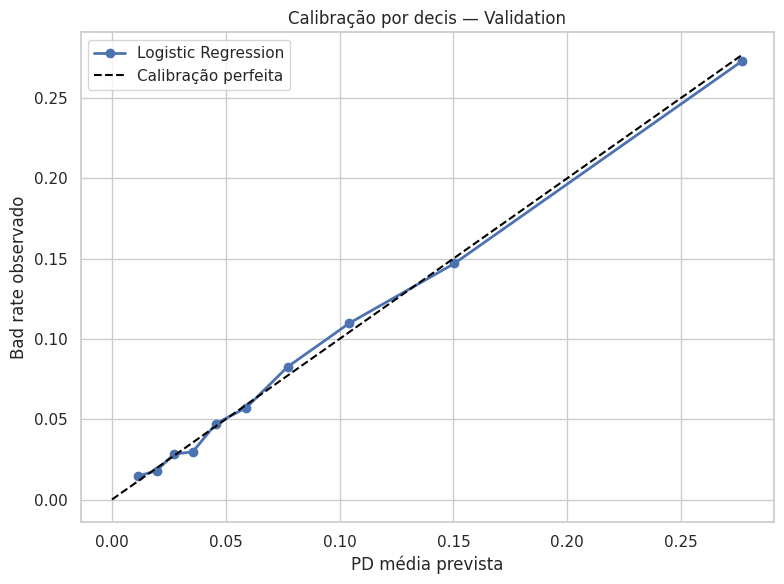

In [84]:
# Visualização da calibração na validation
figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    validation_calibration_table[
        "mean_predicted_pd"
    ],
    validation_calibration_table[
        "observed_bad_rate"
    ],
    marker="o",
    linewidth=2,
    label="Logistic Regression",
)

calibration_limit = max(
    validation_calibration_table[
        "mean_predicted_pd"
    ].max(),
    validation_calibration_table[
        "observed_bad_rate"
    ].max(),
)

axis.plot(
    [
        0,
        calibration_limit,
    ],
    [
        0,
        calibration_limit,
    ],
    linestyle="--",
    color="black",
    label="Calibração perfeita",
)

axis.set_title(
    "Calibração por decis — Validation"
)

axis.set_xlabel(
    "PD média prevista"
)

axis.set_ylabel(
    "Bad rate observado"
)

axis.legend()

plt.tight_layout()
plt.show()

## Avaliação Final no Holdout Test

### 1. Transformação do holdout

Todas as decisões de modelagem foram concluídas utilizando train e validation:

- parâmetros de binning;
- limite mínimo de IV;
- filtro de correlação;
- controle por VIF;
- seleção por sinal dos coeficientes;
- intensidade da regularização.

O holdout test será agora transformado utilizando exatamente os bins e valores WoE aprendidos no train.

Nenhum parâmetro será reajustado com base no resultado do holdout.

In [85]:
# Transformação do holdout test para WoE
X_holdout_test_woe = (
    transform_features_to_woe(
        dataframe=X_holdout_test,
        feature_names=traditional_features,
        fitted_binning_process=(
            binning_process
        ),
    )
)

print(
    f"X_holdout_test_woe: "
    f"{X_holdout_test_woe.shape}"
)

X_holdout_test_woe: (46127, 48)


In [86]:
# Validação da transformação do holdout
holdout_transformation_summary = pd.DataFrame(
    [
        {
            "linhas": (
                X_holdout_test_woe.shape[0]
            ),
            "features": (
                X_holdout_test_woe.shape[1]
            ),
            "missing": int(
                X_holdout_test_woe
                .isna()
                .sum()
                .sum()
            ),
            "infinity": int(
                np.isinf(
                    X_holdout_test_woe
                    .to_numpy()
                ).sum()
            ),
        }
    ]
)

display(
    holdout_transformation_summary
)

,linhas,features,missing,infinity
0,46127,48,0,0


In [87]:
# Cálculo das probabilidades no holdout
traditional_holdout_pd = (
    traditional_model.predict_proba(
        X_holdout_test_woe[
            traditional_features
        ]
    )[:, 1]
)

print(
    "PD média prevista no holdout: "
    f"{traditional_holdout_pd.mean():.4%}"
)

print(
    "Bad rate observado no holdout: "
    f"{y_holdout_test.mean():.4%}"
)

PD média prevista no holdout: 8.0526%
Bad rate observado no holdout: 8.0734%


In [88]:
# Comparação do desempenho entre as amostras
final_evaluation_records = []

for (
    sample_name,
    target,
    predicted_probability,
) in [
    (
        "train",
        y_train,
        traditional_train_pd,
    ),
    (
        "validation",
        y_validation,
        traditional_validation_pd,
    ),
    (
        "holdout_test",
        y_holdout_test,
        traditional_holdout_pd,
    ),
]:
    metrics = calculate_binary_metrics(
        target,
        predicted_probability,
    )

    final_evaluation_records.append(
        {
            "sample": sample_name,
            **metrics,
        }
    )

final_evaluation_table = pd.DataFrame(
    final_evaluation_records
)

display(final_evaluation_table)

,sample,roc_auc,gini,ks,pr_auc,brier_score,log_loss,mean_predicted_pd,observed_event_rate
0,train,0.7642,0.5284,0.3941,0.2480,0.0675,0.2445,0.0807,0.0807
1,validation,0.7618,0.5237,0.3950,0.2461,0.0676,0.2452,0.0807,0.0807
2,holdout_test,0.7654,0.5309,0.4018,0.2464,0.0675,0.2443,0.0805,0.0807


In [89]:
# Construção da calibração no holdout
holdout_calibration_table = (
    build_calibration_table(
        y_true=y_holdout_test,
        predicted_probability=(
            traditional_holdout_pd
        ),
        number_of_bins=10,
    )
)

display(
    holdout_calibration_table
)

,risk_decile,clients,events,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,calibration_difference
0,1,4613,59,0.0021,0.0158,0.0112,0.0128,0.1000,-0.0016
1,2,4613,85,0.0158,0.0231,0.0195,0.0184,0.1000,0.0010
2,3,4612,132,0.0231,0.0310,0.0270,0.0286,0.1000,-0.0016
3,4,4613,143,0.0310,0.0402,0.0355,0.0310,0.1000,0.0045
4,5,4613,205,0.0402,0.0516,0.0457,0.0444,0.1000,0.0012
5,6,4612,276,0.0516,0.0667,0.0587,0.0598,0.1000,-0.0011
6,7,4613,335,0.0667,0.0883,0.0768,0.0726,0.1000,0.0042
7,8,4612,508,0.0883,0.1230,0.1038,0.1101,0.1000,-0.0063
8,9,4613,690,0.1230,0.1865,0.1509,0.1496,0.1000,0.0013
9,10,4613,1291,0.1865,0.6588,0.2761,0.2799,0.1000,-0.0038


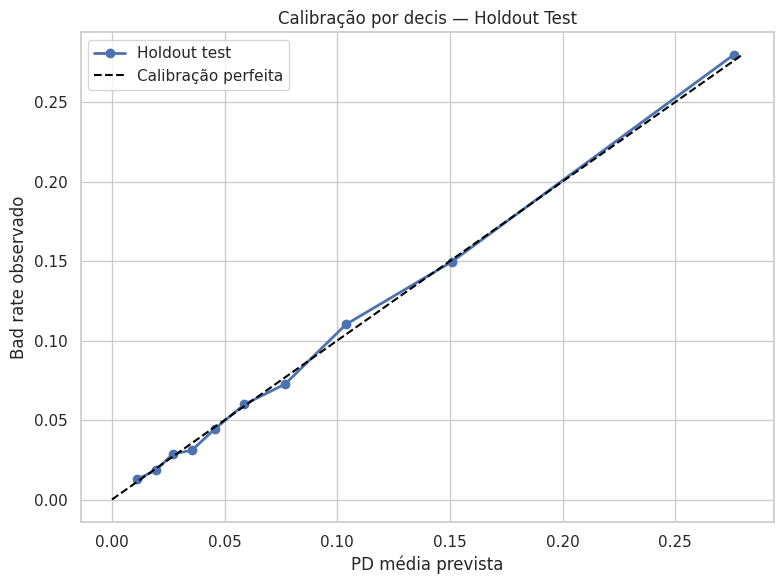

In [90]:
# Visualização da calibração no holdout
figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    holdout_calibration_table[
        "mean_predicted_pd"
    ],
    holdout_calibration_table[
        "observed_bad_rate"
    ],
    marker="o",
    linewidth=2,
    label="Holdout test",
)

calibration_limit = max(
    holdout_calibration_table[
        "mean_predicted_pd"
    ].max(),
    holdout_calibration_table[
        "observed_bad_rate"
    ].max(),
)

axis.plot(
    [
        0,
        calibration_limit,
    ],
    [
        0,
        calibration_limit,
    ],
    linestyle="--",
    color="black",
    label="Calibração perfeita",
)

axis.set_title(
    "Calibração por decis — Holdout Test"
)

axis.set_xlabel(
    "PD média prevista"
)

axis.set_ylabel(
    "Bad rate observado"
)

axis.legend()

plt.tight_layout()
plt.show()

### 2. Incerteza das métricas no holdout

As métricas calculadas no holdout são estimativas sujeitas à variabilidade amostral.

Para quantificar essa incerteza, serão construídos intervalos de confiança de 95% por bootstrap.

Em cada iteração:

1. será gerada uma nova amostra com reposição a partir do holdout;
2. as métricas serão recalculadas;
3. ao final, serão utilizados os percentis 2,5% e 97,5% das distribuições obtidas.

O bootstrap preserva o pareamento entre o target observado e a probabilidade estimada para cada cliente.

In [91]:
# Estimação dos intervalos de confiança por bootstrap
BOOTSTRAP_ITERATIONS = 500
CONFIDENCE_LEVEL = 0.95

random_generator = np.random.default_rng(
    RANDOM_STATE
)

holdout_target_array = np.asarray(
    y_holdout_test
)

holdout_probability_array = np.asarray(
    traditional_holdout_pd
)

number_of_holdout_records = len(
    holdout_target_array
)

bootstrap_records = []

for bootstrap_iteration in range(
    BOOTSTRAP_ITERATIONS
):
    bootstrap_indices = (
        random_generator.integers(
            low=0,
            high=number_of_holdout_records,
            size=number_of_holdout_records,
        )
    )

    bootstrap_target = (
        holdout_target_array[
            bootstrap_indices
        ]
    )

    bootstrap_probability = (
        holdout_probability_array[
            bootstrap_indices
        ]
    )

    bootstrap_metrics = (
        calculate_binary_metrics(
            bootstrap_target,
            bootstrap_probability,
        )
    )

    bootstrap_records.append(
        {
            "roc_auc": (
                bootstrap_metrics[
                    "roc_auc"
                ]
            ),
            "gini": (
                bootstrap_metrics[
                    "gini"
                ]
            ),
            "ks": (
                bootstrap_metrics["ks"]
            ),
            "brier_score": (
                bootstrap_metrics[
                    "brier_score"
                ]
            ),
            "log_loss": (
                bootstrap_metrics[
                    "log_loss"
                ]
            ),
        }
    )

bootstrap_metrics_table = pd.DataFrame(
    bootstrap_records
)

print(
    "Iterações de bootstrap concluídas: "
    f"{len(bootstrap_metrics_table):,}"
)

Iterações de bootstrap concluídas: 500


In [92]:
# Construção dos intervalos de confiança
alpha = 1 - CONFIDENCE_LEVEL

holdout_point_metrics = (
    calculate_binary_metrics(
        y_holdout_test,
        traditional_holdout_pd,
    )
)

confidence_interval_records = []

for metric_name in [
    "roc_auc",
    "gini",
    "ks",
    "brier_score",
    "log_loss",
]:
    confidence_interval_records.append(
        {
            "metric": metric_name,
            "point_estimate": (
                holdout_point_metrics[
                    metric_name
                ]
            ),
            "bootstrap_mean": (
                bootstrap_metrics_table[
                    metric_name
                ].mean()
            ),
            "ci_lower_95": (
                bootstrap_metrics_table[
                    metric_name
                ].quantile(
                    alpha / 2
                )
            ),
            "ci_upper_95": (
                bootstrap_metrics_table[
                    metric_name
                ].quantile(
                    1 - alpha / 2
                )
            ),
        }
    )

holdout_confidence_intervals = (
    pd.DataFrame(
        confidence_interval_records
    )
)

display(
    holdout_confidence_intervals
)

,metric,point_estimate,bootstrap_mean,ci_lower_95,ci_upper_95
0,roc_auc,0.7654,0.7654,0.7578,0.7734
1,gini,0.5309,0.5309,0.5156,0.5468
2,ks,0.4018,0.4038,0.3879,0.4190
3,brier_score,0.0675,0.0675,0.0657,0.0696
4,log_loss,0.2443,0.2443,0.2388,0.2505


## Persistência dos Artefatos

Os artefatos necessários para reproduzir as previsões serão persistidos separadamente:

- processo de binning;
- Logistic Regression;
- lista ordenada das features;
- configuração do modelo;
- coeficientes;
- métricas finais;
- intervalos de confiança;
- tabelas de calibração;
- probabilidades estimadas para cada amostra.

Os artefatos pesados serão armazenados no cache do Google Drive. As tabelas resumidas serão armazenadas em `reports/tables`, podendo ser versionadas com o projeto.

In [93]:
# Construção da tabela final de coeficientes
traditional_final_vif = (
    calculate_vif_from_correlation(
        X_train_woe[
            traditional_features
        ]
    )
)

traditional_coefficient_table = (
    pd.DataFrame(
        {
            "feature": traditional_features,
            "coefficient": (
                traditional_model.coef_[0]
            ),
        }
    )
)

traditional_coefficient_table[
    "absolute_coefficient"
] = traditional_coefficient_table[
    "coefficient"
].abs()

traditional_coefficient_table[
    "odds_ratio_per_woe_unit"
] = np.exp(
    traditional_coefficient_table[
        "coefficient"
    ]
)

traditional_coefficient_table[
    "iv"
] = traditional_coefficient_table[
    "feature"
].map(iv_by_feature)

traditional_coefficient_table[
    "psi_validation"
] = traditional_coefficient_table[
    "feature"
].map(
    psi_summary.set_index(
        "feature"
    )["psi_validation"]
)

traditional_coefficient_table[
    "vif"
] = traditional_coefficient_table[
    "feature"
].map(
    traditional_final_vif
)

traditional_coefficient_table = (
    traditional_coefficient_table
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    traditional_coefficient_table.head(20)
)

,feature,coefficient,absolute_coefficient,odds_ratio_per_woe_unit,iv,psi_validation,vif
0,CODE_GENDER,-0.6357,0.6357,0.5296,0.0387,0.0001,1.2335
1,POS_COMPLETION_RATIO_MEAN,-0.6228,0.6228,0.5364,0.0226,0.0001,1.2278
2,EXT_SOURCE_MEAN,-0.6148,0.6148,0.5408,0.6219,0.0002,2.0973
3,OWN_CAR_AGE,-0.5458,0.5458,0.5794,0.0222,0.0000,1.1057
4,CREDIT_GOODS_RATIO,-0.5391,0.5391,0.5833,0.0733,0.0001,1.0735
5,INST_CONTRACT_WITH_LATE_RATIO,-0.5201,0.5201,0.5945,0.0740,0.0001,1.3071
6,INST_PAID_AMOUNT_SUM,-0.4950,0.4950,0.6096,0.0340,0.0002,1.9715
7,NAME_EDUCATION_TYPE,-0.4871,0.4871,0.6144,0.0488,0.0001,1.1809
8,FLAG_DOCUMENT_3,-0.4294,0.4294,0.6509,0.0290,0.0000,1.1201
9,BU_MAX_OVERDUE_MEAN,-0.3964,0.3964,0.6727,0.0239,0.0002,1.0892


In [94]:
# Construção da configuração final do modelo
traditional_model_config = {
    "model_type": "LogisticRegression",
    "target": TARGET_COLUMN,
    "identifier": ID_COLUMN,
    "woe_convention": (
        "log(distribution_non_event / "
        "distribution_event)"
    ),
    "penalty": "l2",
    "C": FINAL_C,
    "solver": "lbfgs",
    "class_weight": None,
    "random_state": RANDOM_STATE,
    "number_of_features": len(
        traditional_features
    ),
    "intercept": float(
        traditional_model.intercept_[0]
    ),
    "minimum_iv": MINIMUM_IV,
    "correlation_threshold": (
        CORRELATION_THRESHOLD
    ),
    "vif_threshold": VIF_THRESHOLD,
    "coefficient_tolerance": (
        COEFFICIENT_TOLERANCE
    ),
}

In [95]:
# Construção das previsões do modelo tradicional
traditional_predictions = pd.concat(
    [
        pd.DataFrame(
            {
                ID_COLUMN: train_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_train.to_numpy()
                ),
                "sample": "train",
                "predicted_pd": (
                    traditional_train_pd
                ),
            }
        ),
        pd.DataFrame(
            {
                ID_COLUMN: validation_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_validation.to_numpy()
                ),
                "sample": "validation",
                "predicted_pd": (
                    traditional_validation_pd
                ),
            }
        ),
        pd.DataFrame(
            {
                ID_COLUMN: holdout_test_df[
                    ID_COLUMN
                ].to_numpy(),
                TARGET_COLUMN: (
                    y_holdout_test.to_numpy()
                ),
                "sample": "holdout_test",
                "predicted_pd": (
                    traditional_holdout_pd
                ),
            }
        ),
    ],
    ignore_index=True,
)

display(
    traditional_predictions.head()
)

print(
    "Total de previsões: "
    f"{len(traditional_predictions):,}"
)

,SK_ID_CURR,TARGET,sample,predicted_pd
0,285133,0,train,0.0208
1,191894,0,train,0.0535
2,369428,0,train,0.1132
3,138717,0,train,0.1027
4,202381,0,train,0.0260


Total de previsões: 307,511


In [96]:
# Definição dos caminhos dos artefatos
TRADITIONAL_MODEL_PATH = (
    paths.models
    / "traditional_logistic_regression.joblib"
)

TRADITIONAL_BINNING_PATH = (
    paths.preprocessing
    / "traditional_binning_process.joblib"
)

TRADITIONAL_FEATURES_PATH = (
    paths.metadata
    / "traditional_final_features.json"
)

TRADITIONAL_CONFIG_PATH = (
    paths.metadata
    / "traditional_model_config.json"
)

TRADITIONAL_COEFFICIENTS_PATH = (
    paths.metadata
    / "traditional_model_coefficients.csv"
)

TRADITIONAL_PREDICTIONS_PATH = (
    paths.data_processed
    / "traditional_model_predictions.parquet"
)

TRADITIONAL_METRICS_PATH = (
    paths.tables
    / "traditional_model_metrics.csv"
)

TRADITIONAL_CONFIDENCE_PATH = (
    paths.tables
    / "traditional_model_confidence_intervals.csv"
)

TRADITIONAL_VALIDATION_CALIBRATION_PATH = (
    paths.tables
    / "traditional_validation_calibration.csv"
)

TRADITIONAL_HOLDOUT_CALIBRATION_PATH = (
    paths.tables
    / "traditional_holdout_calibration.csv"
)

In [97]:
# Persistência dos artefatos do modelo tradicional
joblib.dump(
    traditional_model,
    TRADITIONAL_MODEL_PATH,
)

joblib.dump(
    binning_process,
    TRADITIONAL_BINNING_PATH,
)

with open(
    TRADITIONAL_FEATURES_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        traditional_features,
        file,
        ensure_ascii=False,
        indent=2,
    )

with open(
    TRADITIONAL_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        traditional_model_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

traditional_coefficient_table.to_csv(
    TRADITIONAL_COEFFICIENTS_PATH,
    index=False,
)

traditional_predictions.to_parquet(
    TRADITIONAL_PREDICTIONS_PATH,
    index=False,
)

final_evaluation_table.to_csv(
    TRADITIONAL_METRICS_PATH,
    index=False,
)

holdout_confidence_intervals.to_csv(
    TRADITIONAL_CONFIDENCE_PATH,
    index=False,
)

validation_calibration_table.to_csv(
    TRADITIONAL_VALIDATION_CALIBRATION_PATH,
    index=False,
)

holdout_calibration_table.to_csv(
    TRADITIONAL_HOLDOUT_CALIBRATION_PATH,
    index=False,
)

print("Artefatos persistidos com sucesso.")

Artefatos persistidos com sucesso.


In [98]:
# Validação dos artefatos persistidos
traditional_artifact_paths = {
    "model": TRADITIONAL_MODEL_PATH,
    "binning_process": (
        TRADITIONAL_BINNING_PATH
    ),
    "features": TRADITIONAL_FEATURES_PATH,
    "config": TRADITIONAL_CONFIG_PATH,
    "coefficients": (
        TRADITIONAL_COEFFICIENTS_PATH
    ),
    "predictions": (
        TRADITIONAL_PREDICTIONS_PATH
    ),
    "metrics": TRADITIONAL_METRICS_PATH,
    "confidence_intervals": (
        TRADITIONAL_CONFIDENCE_PATH
    ),
    "validation_calibration": (
        TRADITIONAL_VALIDATION_CALIBRATION_PATH
    ),
    "holdout_calibration": (
        TRADITIONAL_HOLDOUT_CALIBRATION_PATH
    ),
}

traditional_artifact_inventory = (
    pd.DataFrame(
        [
            {
                "artifact": artifact_name,
                "path": str(artifact_path),
                "exists": (
                    artifact_path.exists()
                ),
                "size_bytes": (
                    artifact_path.stat().st_size
                    if artifact_path.exists()
                    else np.nan
                ),
            }
            for artifact_name, artifact_path
            in traditional_artifact_paths.items()
        ]
    )
)

display(
    traditional_artifact_inventory
)

,artifact,path,exists,size_bytes
0,model,/content/drive/MyDrive/home-credit-default-ris...,True,2607
1,binning_process,/content/drive/MyDrive/home-credit-default-ris...,True,896004
2,features,/content/drive/MyDrive/home-credit-default-ris...,True,1271
3,config,/content/drive/MyDrive/home-credit-default-ris...,True,438
4,coefficients,/content/drive/MyDrive/home-credit-default-ris...,True,6919
5,predictions,/content/drive/MyDrive/home-credit-default-ris...,True,4533225
6,metrics,/content/home-credit-default-risk/reports/tabl...,True,587
7,confidence_intervals,/content/home-credit-default-risk/reports/tabl...,True,484
8,validation_calibration,/content/home-credit-default-risk/reports/tabl...,True,1449
9,holdout_calibration,/content/home-credit-default-risk/reports/tabl...,True,1458


## Visualizações Finais

As visualizações finais resumem três aspectos do modelo:

- discriminação por meio da curva ROC;
- separação entre eventos e não eventos por meio do KS;
- importância e direção dos coeficientes da Logistic Regression.

As figuras serão persistidas em `reports/figures`.

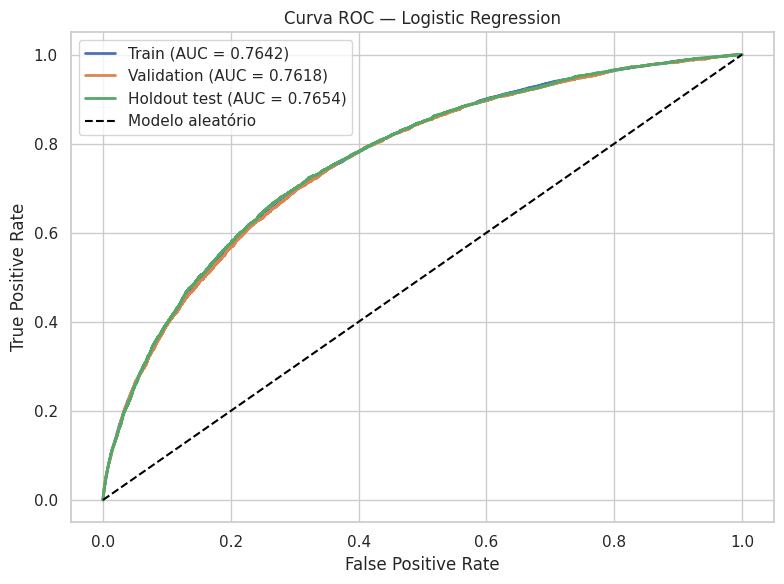

In [99]:
# Visualização das curvas ROC
figure, axis = plt.subplots(
    figsize=(8, 6)
)

roc_samples = [
    (
        "Train",
        y_train,
        traditional_train_pd,
    ),
    (
        "Validation",
        y_validation,
        traditional_validation_pd,
    ),
    (
        "Holdout test",
        y_holdout_test,
        traditional_holdout_pd,
    ),
]

for (
    sample_name,
    target,
    probability,
) in roc_samples:
    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            target,
            probability,
        )
    )

    auc_value = roc_auc_score(
        target,
        probability,
    )

    axis.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{sample_name} "
            f"(AUC = {auc_value:.4f})"
        ),
    )

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Modelo aleatório",
)

axis.set_title(
    "Curva ROC — Logistic Regression"
)

axis.set_xlabel(
    "False Positive Rate"
)

axis.set_ylabel(
    "True Positive Rate"
)

axis.legend()

plt.tight_layout()

ROC_FIGURE_PATH = (
    paths.figures
    / "traditional_model_roc_curve.png"
)

plt.savefig(
    ROC_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

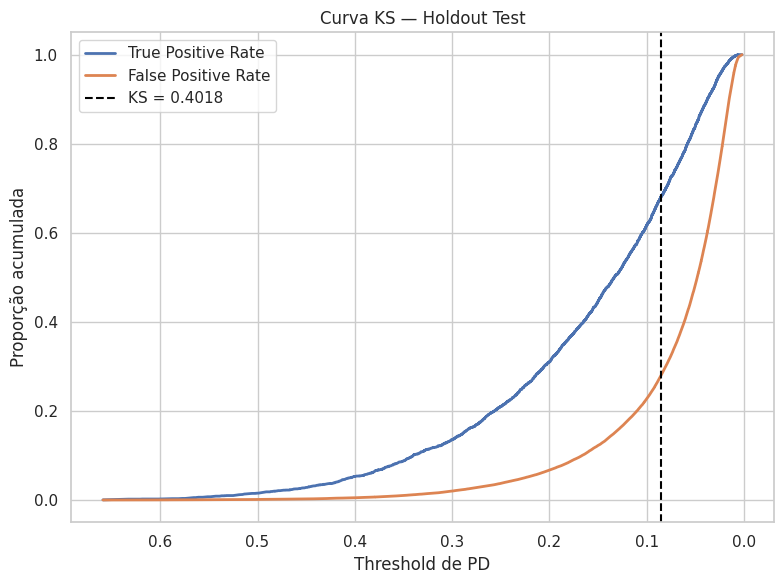

In [102]:
# Visualização do KS no holdout
holdout_fpr, holdout_tpr, holdout_thresholds = (
    roc_curve(
        y_holdout_test,
        traditional_holdout_pd,
    )
)

holdout_ks_values = (
    holdout_tpr
    - holdout_fpr
)

holdout_ks_index = int(
    np.argmax(
        holdout_ks_values
    )
)

holdout_ks_value = (
    holdout_ks_values[
        holdout_ks_index
    ]
)

holdout_ks_threshold = (
    holdout_thresholds[
        holdout_ks_index
    ]
)

finite_threshold_mask = np.isfinite(
    holdout_thresholds
)

figure, axis = plt.subplots(
    figsize=(8, 6)
)

axis.plot(
    holdout_thresholds[
        finite_threshold_mask
    ],
    holdout_tpr[
        finite_threshold_mask
    ],
    label="True Positive Rate",
    linewidth=2,
)

axis.plot(
    holdout_thresholds[
        finite_threshold_mask
    ],
    holdout_fpr[
        finite_threshold_mask
    ],
    label="False Positive Rate",
    linewidth=2,
)

axis.axvline(
    holdout_ks_threshold,
    color="black",
    linestyle="--",
    label=(
        f"KS = {holdout_ks_value:.4f}"
    ),
)

axis.set_title(
    "Curva KS — Holdout Test"
)

axis.set_xlabel(
    "Threshold de PD"
)

axis.set_ylabel(
    "Proporção acumulada"
)

axis.invert_xaxis()
axis.legend()

plt.tight_layout()

KS_FIGURE_PATH = (
    paths.figures
    / "traditional_model_ks_curve.png"
)

plt.savefig(
    KS_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

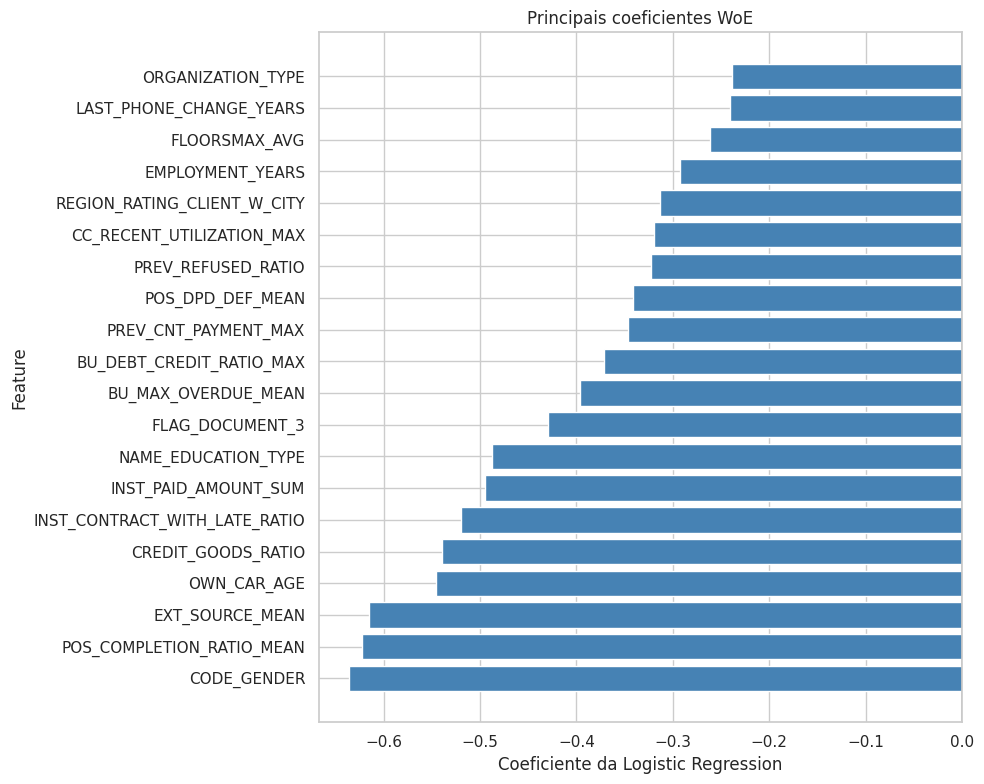

In [103]:
# Visualização dos principais coeficientes
top_coefficient_features = (
    traditional_coefficient_table
    .head(20)
    .sort_values(
        "coefficient",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(10, 8)
)

axis.barh(
    top_coefficient_features[
        "feature"
    ],
    top_coefficient_features[
        "coefficient"
    ],
    color="steelblue",
)

axis.axvline(
    0,
    color="black",
    linewidth=1,
)

axis.set_title(
    "Principais coeficientes WoE"
)

axis.set_xlabel(
    "Coeficiente da Logistic Regression"
)

axis.set_ylabel(
    "Feature"
)

plt.tight_layout()

COEFFICIENT_FIGURE_PATH = (
    paths.figures
    / "traditional_model_coefficients.png"
)

plt.savefig(
    COEFFICIENT_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [104]:
# Validação das figuras persistidas
traditional_figure_inventory = pd.DataFrame(
    [
        {
            "figure": "ROC curve",
            "path": str(
                ROC_FIGURE_PATH
            ),
            "exists": (
                ROC_FIGURE_PATH.exists()
            ),
        },
        {
            "figure": "KS curve",
            "path": str(
                KS_FIGURE_PATH
            ),
            "exists": (
                KS_FIGURE_PATH.exists()
            ),
        },
        {
            "figure": "Coefficients",
            "path": str(
                COEFFICIENT_FIGURE_PATH
            ),
            "exists": (
                COEFFICIENT_FIGURE_PATH.exists()
            ),
        },
    ]
)

display(
    traditional_figure_inventory
)

,figure,path,exists
0,ROC curve,/content/home-credit-default-risk/reports/figu...,True
1,KS curve,/content/home-credit-default-risk/reports/figu...,True
2,Coefficients,/content/home-credit-default-risk/reports/figu...,True


## Conclusão

Este notebook desenvolveu o modelo tradicional de Application Score com base em:

$$
\text{Optimal Binning}
\rightarrow
\text{WoE}
\rightarrow
\text{IV}
\rightarrow
\text{Logistic Regression}
\rightarrow
\text{PD}
$$

O processo começou com 325 features candidatas. Após a avaliação de capacidade preditiva, estabilidade, redundância, multicolinearidade e consistência dos coeficientes, foram selecionadas 48 features para o modelo final.

O funil de seleção foi:

- 325 features candidatas;
- 131 features com $IV \geq 0{,}02$;
- 131 features estáveis na validation;
- 62 features após o filtro de correlação;
- 62 features após a análise de VIF;
- 48 features após o tratamento dos sinais dos coeficientes.

A Logistic Regression final utilizou regularização L2 com $C = 0{,}10$ e não utilizou balanceamento artificial das classes, preservando a interpretação probabilística das estimativas.

No holdout test, o modelo apresentou:

| Métrica | Resultado | Intervalo de confiança de 95% |
|---|---:|---:|
| ROC-AUC | 0,7654 | [0,7578; 0,7734] |
| Gini | 0,5309 | [0,5156; 0,5468] |
| KS | 0,4018 | [0,3879; 0,4190] |
| PR-AUC | 0,2464 | — |
| Brier Score | 0,0675 | [0,0657; 0,0696] |
| Log Loss | 0,2443 | [0,2388; 0,2505] |

A PD média prevista no holdout foi de aproximadamente 8,05%, enquanto o bad rate observado foi de 8,07%.

A calibração também se mostrou consistente ao longo dos decis de risco. O bad rate observado cresceu monotonicamente de 1,28% no primeiro decil para 27,99% no último decil.

Os resultados indicam que o modelo apresenta:

- boa capacidade de discriminação;
- estabilidade entre train, validation e holdout;
- calibração adequada;
- coeficientes com direção consistente com a transformação WoE;
- comportamento interpretável para fins de credit scoring.

Entretanto, algumas limitações devem ser consideradas:

- o target representa dificuldade de pagamento conforme a definição da Home Credit e não necessariamente uma definição regulatória de default;
- a divisão entre as amostras é aleatória, e não temporal;
- o PSI calculado representa estabilidade amostral interna, não uma validação Out-of-Time;
- as features `EXT_SOURCE` possuem contribuição relevante e representam scores externos cuja metodologia não é disponibilizada;
- o projeto não dispõe de informações sobre LGD, EAD, rentabilidade ou custo de crédito;
- o modelo estima risco, mas não define sozinho uma decisão de aprovação.

Portanto, a probabilidade estimada deve ser interpretada como um insumo para a Política de Crédito:

> O modelo ordena e estima o risco dos clientes. A decisão de conceder crédito depende também de regras de elegibilidade, estratégia de negócio, apetite a risco, retorno esperado e restrições regulatórias.

Os bins, o processo de transformação WoE, a Logistic Regression, as features selecionadas, os coeficientes, as previsões e as métricas foram persistidos para reutilização nos próximos notebooks.

No próximo notebook será desenvolvido o modelo challenger com LightGBM. Posteriormente, os dois modelos serão comparados no mesmo holdout por meio de métricas de discriminação, calibração, estabilidade e interpretabilidade.